In [1]:
import gc
import os
import random
from itertools import product
from pathlib import Path
from timeit import default_timer as timer

import matplotlib.pyplot as plt
import numpy as np
import pandas as pd
import torch

from IPython.display import display
from sklearn.metrics import (
    average_precision_score,
    ndcg_score,
    r2_score,
    roc_auc_score,
)
from tqdm.auto import tqdm

from DeleteCache import delete_pert_files_and_folders
from experiments import (
    experiment_global_attack_direct,
    experiment_train,
)
from helpers.old_mining_cache_helper import load_saved_candidate_score_cache
from helpers.selector_pipeline_helpers import (
    _edge_set,
    mine_candidate_edge_scores,
    train_selector, sample_random_candidates, _to_numpy, _compute_clean_stats, _flip_candidate_sparse, accuracy,
    _candidates_to_linear_ids
)
from sparse_smoothing.utils import load_and_standardize

%load_ext autoreload
%autoreload 2

PROJECT_DIR = Path.cwd().parent
os.chdir(PROJECT_DIR)

print("PROJECT_DIR:", PROJECT_DIR)
print("Current directory:", Path.cwd())

files = ["cache/demo.json", "cache/demo/demo_1.pt", "cache/evasion_global_adj.json", "cache/evasion_global_attr.json", "cache/evasion_global_adj/evasion_global_adj_1.pt", "cache/evasion_global_attr/evasion_global_attr_1.pt"]

for file_path in files:
    if os.path.exists(file_path):
        os.remove(file_path)
        print(f"{file_path} has been deleted.")
    else:
        print(f"{file_path} does not exist.")

%matplotlib inline




Use from seml.experiment import setup_logger instead.
Note that seml.experiment.Experiment already includes the logger setup.
See https://github.com/TUM-DAML/seml/blob/master/examples/example_experiment.py


[08/22/26 14:35:19] WARNING  Importing setup_logger directly from seml is deprecated.                ]8;id=797826;file://E:\Anaconda\envs\Masterarbeit\Lib\site-packages\seml\__init__.py\__init__.py]8;;\:]8;id=382322;file://E:\Anaconda\envs\Masterarbeit\Lib\site-packages\seml\__init__.py#10\10]8;;\
                             Use from seml.experiment import setup_logger instead.                                 
                             Note that seml.experiment.Experiment already includes the logger setup.               
                             See                                                                                   
                             https://github.com/TUM-DAML/seml/blob/master/examples/example_experimen               
                             t.py                                                                                  

PROJECT_DIR: E:\Masterarbeit\AttackerGNN
Current directory: E:\Masterarbeit\AttackerGNN
cache/demo.json does not exist.
cache/demo/demo_1.pt does not exist.
cache/evasion_global_adj.json has been deleted.
cache/evasion_global_attr.json has been deleted.
cache/evasion_global_adj/evasion_global_adj_1.pt has been deleted.
cache/evasion_global_attr/evasion_global_attr_1.pt has been deleted.


In [3]:
# ── Dataset / Experiment seeds ─────────────────────────────────────────────────────────
DATASET = 'cora_ml'

# All experiments in this notebook are repeated for these seeds.
SEEDS = [0]
N_SEEDS = len(SEEDS)

# ── Victim model params ─────────────────────────────────────────────────────────────
MODEL_NAME = 'GCN'
MODEL_LABEL = 'GCN'
DROPOUT_VICTIM = 0.5
LR_VICTIM = 1e-2
WEIGHT_DECAY_VICTIM = 1e-3
PATIENCE_VICTIM = 300
MAX_EPOCHS_VICTIM = 3000

# ── Label mining and candidate set construction ────────────────────────────────────────
CANDIDATE_SET_SIZES = [1000]
PRBCD_CANDIDATE_FRACTIONS = [0.0]
SCORING_MODES = ["endpoint","subset_accuracy_drop"]

# ── Logging ─────────────────────────────────────────────────────────

RQ2_OUT_DIR = Path("extendedPlotting/final_runs/RQ2")
RQ2_OUT_DIR.mkdir(parents=True, exist_ok=True)

RQ3_OUT_DIR = Path("extendedPlotting/final_runs/RQ3")
RQ3_OUT_DIR.mkdir(parents=True, exist_ok=True)

# ── Subset acuracy drop scoring parameters ─────────────────────────────────────────────────
N_SUBSETS = 1000
SUBSET_EXTREME_FRACTION = 0.10

# ── Selector training params ───────────────────────────────────────────────────
SELECTOR_HIDDEN = 64
SELECTOR_EPOCHS = 1000
SELECTOR_LR = 5e-4
SELECTOR_PATIENCE = 20

print(f"Configured {N_SEEDS} seeds: {SEEDS}")


Configured 1 seeds: [0]


Training victim model for seed=0


[08/22/26 14:36:31] INFO     {'dataset': 'cora_ml', 'model_params': {'label': 'GCN',        ]8;id=446915;file://E:\Masterarbeit\AttackerGNN\experiments\experiment_train.py\experiment_train.py]8;;\:]8;id=598664;file://E:\Masterarbeit\AttackerGNN\experiments\experiment_train.py#180\180]8;;\
                             'model': 'GCN', 'do_cache_adj_prep': True, 'n_filters': 64,                           
                             'dropout': 0.5, 'svd_params': None, 'jaccard_params': None,                           
                             'gdc_params': {'alpha': 0.15, 'k': 64}}, 'train_params':                              
                             {'lr': 0.01, 'weight_decay': 0.001, 'patience': 300,                                  
                             'max_epochs': 3000}, 'binary_attr': False, 'make_undirected':                         
                             True, 'seed': 0, 'artifact_dir': 'cache',                                             
                             'model_storage_type': 'demo_custom_split', 'ppr_cache_params':                        
                             {}, 'device': 'cpu', 'display_steps': 100, 'data_device':                             
                             'cpu'}                                                                                

                    INFO     Training set size: 140                                         ]8;id=897630;file://E:\Masterarbeit\AttackerGNN\experiments\experiment_train.py\experiment_train.py]8;;\:]8;id=53497;file://E:\Masterarbeit\AttackerGNN\experiments\experiment_train.py#216\216]8;;\

                    INFO     Validation set size: 140                                       ]8;id=707874;file://E:\Masterarbeit\AttackerGNN\experiments\experiment_train.py\experiment_train.py]8;;\:]8;id=168925;file://E:\Masterarbeit\AttackerGNN\experiments\experiment_train.py#217\217]8;;\

                    INFO     Test set size: 2530                                            ]8;id=609470;file://E:\Masterarbeit\AttackerGNN\experiments\experiment_train.py\experiment_train.py]8;;\:]8;id=804165;file://E:\Masterarbeit\AttackerGNN\experiments\experiment_train.py#218\218]8;;\

...

[08/22/26 14:36:45] INFO                                                                                ]8;id=737362;file://E:\Masterarbeit\AttackerGNN\rgnn_at_scale\train.py\train.py]8;;\:]8;id=57127;file://E:\Masterarbeit\AttackerGNN\rgnn_at_scale\train.py#81\81]8;;\
                             Epoch  500: loss_train: 0.06982, loss_val: 0.36410, acc_train: 1.00000,               
                             acc_val: 0.88571                                                                      

[08/22/26 14:36:48] INFO                                                                                ]8;id=144383;file://E:\Masterarbeit\AttackerGNN\rgnn_at_scale\train.py\train.py]8;;\:]8;id=278321;file://E:\Masterarbeit\AttackerGNN\rgnn_at_scale\train.py#81\81]8;;\
                             Epoch  600: loss_train: 0.06437, loss_val: 0.40359, acc_train: 1.00000,               
                             acc_val: 0.87857                                                                      

[08/22/26 14:36:50] INFO     Test accuracy is 0.8351778388023376 with seed 0                ]8;id=339666;file://E:\Masterarbeit\AttackerGNN\experiments\experiment_train.py\experiment_train.py]8;;\:]8;id=886338;file://E:\Masterarbeit\AttackerGNN\experiments\experiment_train.py#271\271]8;;\

                    INFO     Lock 1984205317328 acquired on cache\demo_custom_split.json.lock       ]8;id=196976;file://E:\Anaconda\envs\Masterarbeit\Lib\site-packages\filelock.py\filelock.py]8;;\:]8;id=202989;file://E:\Anaconda\envs\Masterarbeit\Lib\site-packages\filelock.py#274\274]8;;\

                    INFO     Lock 1984205317328 released on cache\demo_custom_split.json.lock       ]8;id=787717;file://E:\Anaconda\envs\Masterarbeit\Lib\site-packages\filelock.py\filelock.py]8;;\:]8;id=423646;file://E:\Anaconda\envs\Masterarbeit\Lib\site-packages\filelock.py#318\318]8;;\

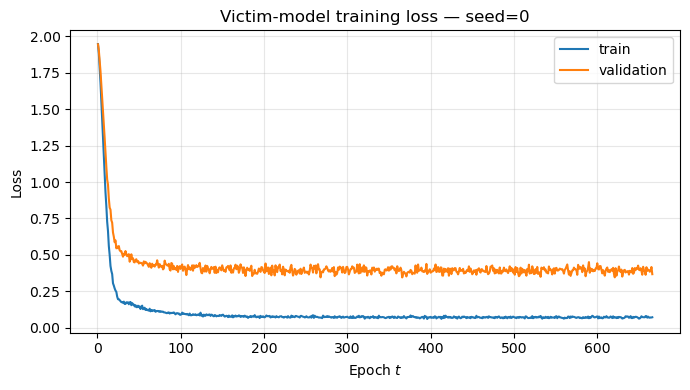

Seed 0: clean accuracy = 83.52%


In [4]:

seed_victim_runs = []
for seed in SEEDS:
    print(f"Training victim model for seed={seed}")

    stats = experiment_train.run(
        data_dir='./data',
        dataset=DATASET,
        model_params=dict(
            label=MODEL_LABEL,
            model=MODEL_NAME,
            do_cache_adj_prep=True,
            n_filters=64,
            dropout=DROPOUT_VICTIM,
            svd_params=None,
            jaccard_params=None,
            gdc_params={"alpha": 0.15, "k": 64},
        ),
        train_params=dict(
            lr=LR_VICTIM,
            weight_decay=WEIGHT_DECAY_VICTIM,
            patience=PATIENCE_VICTIM,
            max_epochs=MAX_EPOCHS_VICTIM,
        ),
        binary_attr=False,
        make_undirected=True,
        seed=seed,
        artifact_dir='cache',
        model_storage_type='demo_custom_split',
        ppr_cache_params=dict(),
        device="cpu",
        data_device="cpu",
        display_steps=100,
        debug_level="info",
        custom_split_ratios=None,
    )

    model_seed = stats["model"]
    graph_seed = stats["graph"]
    idx_train_seed = stats["idx_train"]
    idx_val_seed = stats["idx_val"]
    idx_test_seed = stats["idx_test"]
    model_seed.eval()

    attr_matrix_seed, adj_matrix_seed, labels_raw_seed = graph_seed[:3]
    model_device = next(model_seed.parameters()).device
    row, col, value = adj_matrix_seed.coo()
    edge_index_seed = torch.stack([row, col], dim=0).long().to(model_device)
    edge_weight_seed = (
        torch.ones(edge_index_seed.size(1), dtype=torch.float32, device=model_device)
        if value is None else value.float().to(model_device)
    )
    attr_seed = attr_matrix_seed.float().to(model_device)
    labels_seed = labels_raw_seed.long().to(model_device)
    n_nodes_seed = int(adj_matrix_seed.sizes()[0])
    n_edges_directed_seed = int(adj_matrix_seed.nnz())
    n_undirected_seed = n_edges_directed_seed // 2
    n_edges_possible_seed = n_nodes_seed * (n_nodes_seed - 1) // 2
    clean_acc_seed = float(stats["accuracy"])

    context = {
        "seed": int(seed),
        "dataset": DATASET,
        "train_statistics": stats,
        "clean_acc": clean_acc_seed,
        "model": model_seed,
        "graph": graph_seed,
        "idx_train": idx_train_seed,
        "idx_val": idx_val_seed,
        "idx_test": idx_test_seed,
        "device": model_device,
        "n_nodes": n_nodes_seed,
        "n_edges_directed": n_edges_directed_seed,
        "n_edges_undirected": n_undirected_seed,
        "n_edges_possible": n_edges_possible_seed,
        "attr_matrix": attr_matrix_seed,
        "adj_matrix": adj_matrix_seed,
        "labels_raw": labels_raw_seed,
        "edge_index": edge_index_seed,
        "edge_weight": edge_weight_seed,
        "attr": attr_seed,
        "labels": labels_seed,
    }

    seed_victim_runs.append(context)

    train_loss = stats.get("trace_train", [])
    val_loss = stats.get("trace_val", [])

    plt.figure(figsize=(7, 4))

    if train_loss:
        plt.plot(range(1, len(train_loss) + 1), train_loss, label="train",)
    if val_loss:
        plt.plot(range(1, len(val_loss) + 1), val_loss, label="validation")

    plt.xlabel(r"Epoch $t$")
    plt.ylabel("Loss")
    plt.title(f"Victim-model training loss — seed={seed}")
    plt.legend()
    plt.grid(alpha=0.3)
    plt.tight_layout()
    plt.show()

    print(
        f"Seed {seed}: "
        f"clean accuracy = {100 * clean_acc_seed:.2f}%"
    )

SEED_CONTEXTS = seed_victim_runs

# Study 2 — Mining Harmful Edge Flips

RQ2 investigates whether a local or global harmfulness objective can generate a sufficiently non-degenerate and reliable harmful edge signal that can enrich the search space of a PR-BCD attack.

Two harmfulness objectives are evaluated:

- **Endpoint:** an edge receives a binary harmfulness label depending on whether flipping it causes at least one previously correctly classified endpoint to become misclassified by the victim model.
- **Subset accuracy drop:** an edge receives a continuous score according to the victim-accuracy reductions of randomly sampled edge subsets in which it occurs.

The usefulness of these labels is evaluated according to three criteria:

1. **Non-degeneracy:** the labels must contain sufficient variation to distinguish candidate edges.
2. **Conditional harmfulness:** high-harmfulness edges should reduce victim accuracy more strongly than low-harmfulness or random edges when applied jointly.
3. **PR-BCD usefulness:** high-harmfulness edges should provide a more useful restricted PR-BCD optimization space.

The following cell first samples the candidate sets \(\mathcal{C}\) from the complete possible edge universe \(\Omega\) for every victim-model seed and configured candidate-set size.

In [4]:

candidate_runs = []
for context in SEED_CONTEXTS:
    seed = int(context["seed"])
    n_nodes = int(context["n_nodes"])
    edge_index = context["edge_index"]
    orig_edges = _edge_set(edge_index)
    for candidate_set_size in CANDIDATE_SET_SIZES:
        candidate_seed = (seed + 20 * candidate_set_size + 17)
        random_candidates = sample_random_candidates(
            num_nodes=n_nodes,
            count=candidate_set_size,
            seed=candidate_seed,
        )
        candidates_for_config = list(random_candidates)
        random.Random(candidate_seed + 1).shuffle(candidates_for_config)
        n_delete_candidates = sum(edge in orig_edges for edge in candidates_for_config)
        n_add_candidates = (candidate_set_size - n_delete_candidates)
        candidate_runs.append({
            "seed": seed,
            "context": context,
            "candidate_set_size": candidate_set_size,
            "n_add_candidates": n_add_candidates,
            "n_delete_candidates": n_delete_candidates,
            "candidates": candidates_for_config,
        })

# Created candidate set summaries.
candidate_config_raw_df = pd.DataFrame([
    {
        key: value
        for key, value in run.items()
        if key not in {
            "context",
            "candidates",
        }
    }
    for run in candidate_runs
])

display(candidate_config_raw_df)
print(
    f"Created {len(candidate_runs)} candidate runs = "
    f"{len(SEEDS)} seeds × "
    f"{len(CANDIDATE_SET_SIZES)} candidate-set sizes."
)

,candidate_set_size,n_add_candidates_mean,n_add_candidates_std,n_add_candidates_count,n_delete_candidates_mean,n_delete_candidates_std,n_delete_candidates_count,n_add_candidates_sem,n_delete_candidates_sem,n_seeds
0,1000,999.0,0.0,1,1.0,0.0,1,0.0,0.0,1


Created 1 candidate runs = 1 seeds × 1 candidate-set sizes.


## Harmfulness Mining Objectives

For every victim-model seed, the same sampled candidate set \(\mathcal{C}\) is evaluated using both harmfulness objectives.

### Local Endpoint Harmfulness

Each candidate edge \(e=\{u,v\}\) is flipped individually. The candidate receives endpoint label

\[
z^{\mathrm{end}}(e)=1
\]

if at least one of its endpoints changes from a correct clean prediction to an incorrect prediction after the edge flip. Otherwise,

\[
z^{\mathrm{end}}(e)=0.
\]

The resulting endpoint labels therefore provide a binary local harmfulness signal.

### Subset Accuracy-Drop Harmfulness

Random subsets \(S_m \subseteq \mathcal{C}\) are sampled and all contained candidate edges are flipped jointly. For every sampled subset, the non-negative reduction in victim accuracy relative to the clean graph is calculated.

The resulting accuracy drop is added to the raw score of every candidate contained in the subset:

\[
r^{\mathrm{sub}}(e)
=
\sum_{m:e\in S_m} d_m^{\mathrm{sub}}.
\]

The raw scores are subsequently min-max normalized over all observed candidates to obtain continuous subset accuracy-drop labels

\[
z^{\mathrm{sub}}(e)\in[0,1].
\]

Candidates that were never included in a sampled subset are excluded from subsequent analyses.

The following cell loads previously computed mining results where available and otherwise evaluates the missing candidate configurations directly on the victim model. The resulting `mining_runs` provide the common input to all remaining RQ2 experiments and to selector training in RQ3.

In [5]:

# Load already scored candidate sets from old runs
OLD_MINING_DIR = Path("path/to/old/candidate_mining_files")

saved_mining_cache = load_saved_candidate_score_cache(
    OLD_MINING_DIR,
    dataset=DATASET,
    seeds=SEEDS,
    n_nodes=SEED_CONTEXTS[0]["n_nodes"],
    candidate_set_sizes=CANDIDATE_SET_SIZES,
    scoring_modes=SCORING_MODES,
    model_name="GCN",
    subset_fraction=SUBSET_EXTREME_FRACTION,
    n_subsets=N_SUBSETS,
)

# Run label mining for all candidate sets.
mining_runs = []
for candidate_run in candidate_runs:

    context = candidate_run["context"]
    seed = int(candidate_run["seed"])
    model = context["model"]
    attr = context["attr"]
    edge_index = context["edge_index"]
    labels = context["labels"]
    idx_test = context["idx_test"]
    n_nodes = int(context["n_nodes"])
    device = attr.device
    candidate_set_size = candidate_run["candidate_set_size"]

    for scoring_mode in SCORING_MODES:

        #Below logic loads old scored candidate sets.
        cache_key = (seed, candidate_set_size, scoring_mode)
        cached = saved_mining_cache.get(cache_key)

        if cached is not None:
            saved = cached["saved"]
            candidates = [(int(u), int(v)) for u, v in saved["candidates"]]
            result = saved["mining_result"]

            print(
                f"\nLoading seed={seed} | "
                f"{candidate_set_size} | "
                f"mode={scoring_mode}"
            )

            print(f"  {cached['path'].name}")

        # This logic scores new candidate edges if old ones are not available
        else:
            candidates = list(candidate_run["candidates"])

            print(f"\nScoring seed={seed} | "f"{candidate_run['candidate_set_size']} | "f"mode={scoring_mode}")
            result = mine_candidate_edge_scores(
                model=model,
                attr=attr,
                edge_index=edge_index,
                labels=labels,
                eval_idx=idx_test,
                candidates=candidates,
                n_nodes=n_nodes,
                mode=scoring_mode,
                subset_fraction=SUBSET_EXTREME_FRACTION,
                n_subsets=N_SUBSETS,
                seed=seed,
                device=device,
            )

        scored_candidates = list(candidates)

        score_raw = np.asarray(result["labels_raw"], dtype=np.float64).reshape(-1)
        score_norm = np.asarray(result["labels_norm"],dtype=np.float32).reshape(-1)

        exists = np.asarray(result.get("exists").reshape(-1))

        # Remove unobserved candidate edges, only relevant for subset accuracy drop scores.
        if scoring_mode == "subset_accuracy_drop":
            inclusion_count = np.asarray(result["inclusion_count"],dtype=np.int64).reshape(-1)
            observed_mask = inclusion_count > 0
        else:
            inclusion_count = np.ones(len(scored_candidates),dtype=np.int64)
            observed_mask = np.ones(len(scored_candidates),dtype=bool)

        n_total = len(scored_candidates)
        n_observed = int(observed_mask.sum())
        n_unobserved = n_total - n_observed
        scored_candidates = [
            candidate
            for candidate, observed
            in zip(scored_candidates, observed_mask)
            if observed
        ]
        score_raw = score_raw[observed_mask]
        score_norm = score_norm[observed_mask]
        exists = exists[observed_mask]
        inclusion_count = inclusion_count[observed_mask]
        src = np.asarray([u for u, _ in scored_candidates],dtype=np.int64)
        dst = np.asarray([v for _, v in scored_candidates],dtype=np.int64)
        n_positive = int(np.sum(score_norm > 0))
        clean_accuracy = float(result["clean_accuracy"])

        # Store results for RQ2 experiments and selector training
        run = {
            "seed": seed,
            "context": context,
            "candidate_set_size": candidate_set_size,
            "scoring_mode": scoring_mode,
            "candidate_pool": candidates,
            "candidates": scored_candidates,
            "n_candidates_total": n_total,
            "n_cands": n_observed,
            "n_unobserved_candidates": n_unobserved,
            "score_raw": score_raw,
            "score_norm": score_norm,
            "labels_raw":score_raw,
            "labels_norm": score_norm,
            "labels_changed":
                torch.tensor(
                    score_norm,
                    dtype=torch.float32,
                    device=device,
                ),
            "src":
                torch.tensor(
                    src,
                    dtype=torch.long,
                    device=device,
                ),
            "dst":
                torch.tensor(
                    dst,
                    dtype=torch.long,
                    device=device,
                ),
            "exists":
                torch.tensor(
                    exists,
                    dtype=torch.float32,
                    device=device,
                ),
            "inclusion_count":inclusion_count,
            "clean_accuracy": clean_accuracy,
            "n_positive_labels": n_positive,
            "mining_result": result,
        }

        mining_runs.append(run)

[MINING CACHE] Folder does not exist: path\to\old\candidate_mining_files. No saved candidate scores loaded.

Scoring seed=0 | 1000 | mode=endpoint
Clean accuracy: 0.8352
Candidates evaluated: 1000
Endpoint hits: 105/1000 (10.50%)

Scoring seed=0 | 1000 | mode=subset_accuracy_drop


KeyboardInterrupt: 

## Experiment 1 — Node Level Diagnostics of Labels

The first validation experiment investigates whether the two mining objectives distinguish candidate edges with different structural and victim-model properties.

For endpoint harmfulness, the candidate set is divided into:

$$
\mathcal{C}^{\mathrm{end},1}
=
\{e\in\mathcal{C}\mid z^{\mathrm{end}}(e)=1\}
$$

and

$$
\mathcal{C}^{\mathrm{end},0}
=
\{e\in\mathcal{C}\mid z^{\mathrm{end}}(e)=0\}.
$$

For subset accuracy-drop harmfulness, candidates are ordered according to their raw scores $r^{\mathrm{sub}}(e)$, and the top and bottom $10\%$ form the high- and low-score comparison groups.

For the endpoints of every candidate, the experiment evaluates clean-graph degree, PageRank, prediction confidence, prediction margin, clean correctness, true-class agreement, and clean-prediction agreement.

Statistics are calculated separately for every victim-model seed. Group means and within-seed differences are subsequently aggregated across victim-model seeds using their mean and sample standard deviation.

Besides characterizing the harmful candidate groups, label prevalence and raw subset-score variation provide evidence for the **non-degeneracy** requirement of RQ2.

In [6]:
# ============================================================
# RQ2: Compare graph/model properties of candidate edges
#
# endpoint:
#   group 1 = harmful
#   group 0 = non-harmful
#
# subset_accuracy_drop:
#   group 1 = top 10% raw score
#   group 0 = bottom 10% raw score
# ============================================================

RQ2_SUBSET_EXTREME_FRACTION = 0.1

RQ2_LABEL_NODE_LEVEL_OUT_DIR = RQ2_OUT_DIR / "rq2_label_node_level_stats"
RQ2_LABEL_NODE_LEVEL_OUT_DIR.mkdir(parents=True,exist_ok=True)

rows = []
for run_index, run in enumerate(mining_runs):

    seed = int(run["seed"])
    scoring_mode = str(run["scoring_mode"])
    context = run["context"]
    candidate_set_size = run["candidate_set_size"]

    clean_stats = _compute_clean_stats(context)
    candidates = list(run["candidates"])
    exists = _to_numpy(run["exists"]).astype(bool).reshape(-1)
    score_raw = np.asarray(run["score_raw"],dtype=float).reshape(-1)
    labels_changed = _to_numpy(run["labels_changed"]).astype(float).reshape(-1)
    n_candidates = run["n_cands"]

    # Make sure everything is aligned.
    if not (len(exists) == len(score_raw) == len(labels_changed) == n_candidates):
        raise ValueError(
            f"Candidate arrays are not aligned for "
            f"seed={seed}, "
            f"size={candidate_set_size}, "
            f"mode={scoring_mode}."
        )

    # Build comparison groups from ordered scores on the candidate set.
    if scoring_mode == "endpoint":
        # For endpoint labels, just compare label-1 and label-0 candidate edges.
        selected_indices = np.arange(n_candidates)
        comparison_groups = (labels_changed > 0.5).astype(int)
    else:
        # For subset accuracy drop labels use the top and botton 10% of edge labels.
        n_valid = len(score_raw)
        n_per_group = int(np.floor(RQ2_SUBSET_EXTREME_FRACTION * n_valid))

        ordered_indices = np.argsort(score_raw)

        bottom_indices = (ordered_indices[:n_per_group])
        top_indices = (ordered_indices[-n_per_group:])
        selected_indices = np.concatenate([bottom_indices,top_indices])
        comparison_groups = np.concatenate([np.zeros(n_per_group,dtype=int),np.ones(n_per_group,dtype=int)])

        print(
            f"[subset] "
            f"seed={seed} | "
            f"size={candidate_set_size} | "
            f"valid={n_valid} | "
            f"bottom={n_per_group} | "
            f"top={n_per_group} | "
            f"bottom cutoff="
            f"{score_raw[bottom_indices[-1]]:.6f} | "
            f"top cutoff="
            f"{score_raw[top_indices[0]]:.6f}"
        )


    # Compute node level statistics used in RQ2
    for local_index, candidate_index in enumerate(selected_indices):

        u, v = candidates[candidate_index]
        group = int(comparison_groups[local_index])

        action = ("delete" if exists[candidate_index] else "add")

        # Compute node level statistics for candidate comparison groups
        degree_u = float(clean_stats["degree"][u])
        degree_v = float(clean_stats["degree"][v])
        pagerank_u = float(clean_stats["pagerank"][u])
        pagerank_v = float(clean_stats["pagerank"][v])
        confidence_u = float(clean_stats["confidence"][u])
        confidence_v = float(clean_stats["confidence"][v])
        margin_u = float(clean_stats["margin"][u])
        margin_v = float(clean_stats["margin"][v])
        true_u = int(clean_stats["labels"][u])
        true_v = int(clean_stats["labels"][v])
        pred_u = int(clean_stats["prediction"][u])
        pred_v = int(clean_stats["prediction"][v])


        rows.append({
            "run_index": run_index,
            "seed": seed,
            "candidate_set_size":candidate_set_size,
            "scoring_mode":scoring_mode,
            "candidate_index": candidate_index,
            "u": u,
            "v": v,
            "group": group,
            "group_name":
                (
                    "harmful"
                    if scoring_mode == "endpoint"
                    and group == 1

                    else "non_harmful"
                    if scoring_mode == "endpoint"

                    else "top_10_percent"
                    if group == 1

                    else "bottom_10_percent"
                ),
            "score_raw": float(score_raw[candidate_index]),
            "action": action,

            "u_degree": degree_u,
            "v_degree": degree_v,
            "mean_degree": (degree_u + degree_v) / 2.0,

            "u_pagerank": pagerank_u,
            "v_pagerank": pagerank_v,
            "mean_pagerank": (pagerank_u + pagerank_v) / 2.0,

            "u_margin": margin_u,
            "v_margin": margin_v,
            "min_margin": min(margin_u, margin_v),

            "u_confidence": confidence_u,
            "v_confidence": confidence_v,

            "min_confidence": min(confidence_u, confidence_v),

            "same_true_class": bool(true_u == true_v),
            "same_clean_prediction": bool(pred_u == pred_v),

            "both_endpoints_clean_correct": bool(pred_u == true_u and pred_v == true_v),
        })


node_statistics_df = pd.DataFrame(rows)

# Compute the means over all edges in the partitioned groups.
result_rows = []
for (seed, candidate_set_size, scoring_mode), frame in node_statistics_df.groupby(
    ["seed", "candidate_set_size", "scoring_mode"]
):

    group_harmful = frame[frame["group"] == 1]
    group_nonharmful = frame[frame["group"] == 0]

    result_rows.append({
        "seed": seed,
        "candidate_set_size": candidate_set_size,
        "scoring_mode": scoring_mode,

        "group_1_n": len(group_harmful),
        "group_0_n": len(group_nonharmful),

        "group_1_prevalence": (
            float((frame["group"] == 1).mean())
            if scoring_mode == "endpoint"
            else np.nan
        ),

        "group_0_prevalence": (
            float((frame["group"] == 0).mean())
            if scoring_mode == "endpoint"
            else np.nan
        ),

        "group_1_raw_score": (
            float(group_harmful["score_raw"].mean())
            if scoring_mode == "subset_accuracy_drop"
            else np.nan
        ),

        "group_0_raw_score": (
            float(group_nonharmful["score_raw"].mean())
            if scoring_mode == "subset_accuracy_drop"
            else np.nan
        ),

        "group_1_min_confidence": float(group_harmful["min_confidence"].mean()),
        "group_0_min_confidence": float(group_nonharmful["min_confidence"].mean()),
        "difference_min_confidence": float(
            group_harmful["min_confidence"].mean()
            - group_nonharmful["min_confidence"].mean()
        ),

        "group_1_min_margin": float(group_harmful["min_margin"].mean()),
        "group_0_min_margin": float(group_nonharmful["min_margin"].mean()),
        "difference_min_margin": float(
            group_harmful["min_margin"].mean()
            - group_nonharmful["min_margin"].mean()
        ),

        "group_1_both_clean_correct": float(
            group_harmful["both_endpoints_clean_correct"].mean()
        ),
        "group_0_both_clean_correct": float(
            group_nonharmful["both_endpoints_clean_correct"].mean()
        ),
        "difference_both_clean_correct": float(
            group_harmful["both_endpoints_clean_correct"].mean()
            - group_nonharmful["both_endpoints_clean_correct"].mean()
        ),

        "group_1_same_true_class": float(group_harmful["same_true_class"].mean()),
        "group_0_same_true_class": float(group_nonharmful["same_true_class"].mean()),
        "difference_same_true_class": float(
            group_harmful["same_true_class"].mean()
            - group_nonharmful["same_true_class"].mean()
        ),

        "group_1_same_clean_prediction": float(
            group_harmful["same_clean_prediction"].mean()
        ),
        "group_0_same_clean_prediction": float(
            group_nonharmful["same_clean_prediction"].mean()
        ),
        "difference_same_clean_prediction": float(
            group_harmful["same_clean_prediction"].mean()
            - group_nonharmful["same_clean_prediction"].mean()
        ),

        "group_1_mean_degree": float(group_harmful["mean_degree"].mean()),
        "group_0_mean_degree": float(group_nonharmful["mean_degree"].mean()),
        "difference_mean_degree": float(
            group_harmful["mean_degree"].mean()
            - group_nonharmful["mean_degree"].mean()
        ),

        "group_1_mean_pagerank": float(group_harmful["mean_pagerank"].mean()),
        "group_0_mean_pagerank": float(group_nonharmful["mean_pagerank"].mean()),
        "difference_mean_pagerank": float(
            group_harmful["mean_pagerank"].mean()
            - group_nonharmful["mean_pagerank"].mean()
        ),
    })

rq2_node_level_label_statistics_raw = pd.DataFrame(result_rows)

# Compute the mean over all seeds.
rq2_node_level_label_statistics_results = (
    rq2_node_level_label_statistics_raw
    .drop(columns="seed")
    .groupby(["candidate_set_size", "scoring_mode"])
    .agg(["mean", "std"])
    .reset_index()
)

rq2_node_level_label_statistics_results.columns = [
    "_".join(str(part) for part in column if str(part))
    if isinstance(column, tuple)
    else column
    for column in rq2_node_level_label_statistics_results.columns
]

display(rq2_node_level_label_statistics_results)

rq2_node_level_label_statistics_results.to_csv(
    RQ2_LABEL_NODE_LEVEL_OUT_DIR
    / (
        f"rq2_node_level_label_statistics_{DATASET}"
        f"_candidates{'-'.join(map(str, CANDIDATE_SET_SIZES))}"
        f"_seeds{'-'.join(map(str, SEEDS))}.csv"
    ),
    index=False,
)

print(f"\nSaved to: {RQ2_LABEL_NODE_LEVEL_OUT_DIR.resolve()}")

[subset] seed=0 | size=1000 | valid=1000 | bottom=100 | top=100 | bottom cutoff=0.085375 | top cutoff=0.135572
[subset] seed=0 | size=2000 | valid=2000 | bottom=200 | top=200 | bottom cutoff=0.134782 | top cutoff=0.207904
[subset] seed=1 | size=1000 | valid=1000 | bottom=100 | top=100 | bottom cutoff=0.078260 | top cutoff=0.125691
[subset] seed=1 | size=2000 | valid=2000 | bottom=200 | top=200 | bottom cutoff=0.142292 | top cutoff=0.213833


,candidate_set_size,scoring_mode,group_1_n_mean,group_1_n_std,group_0_n_mean,group_0_n_std,group_1_prevalence_mean,group_1_prevalence_std,group_0_prevalence_mean,group_0_prevalence_std,...,group_0_mean_degree_mean,group_0_mean_degree_std,difference_mean_degree_mean,difference_mean_degree_std,group_1_mean_pagerank_mean,group_1_mean_pagerank_std,group_0_mean_pagerank_mean,group_0_mean_pagerank_std,difference_mean_pagerank_mean,difference_mean_pagerank_std
0,1000,endpoint,109.0,5.656854,891.0,5.656854,0.109,0.005657,0.891,0.005657,...,5.696384,0.095970,-2.248344,0.199745,0.000253,0.000016,0.000353,8.484704e-08,-1.001358e-04,1.584590e-05
1,1000,subset_accuracy_drop,100.0,0.000000,100.0,0.000000,NaN,NaN,NaN,NaN,...,4.852500,0.031820,-0.097500,0.512652,0.000314,0.000031,0.000311,4.088340e-06,3.284419e-06,2.706829e-05
2,2000,endpoint,202.0,1.414214,1798.0,1.414214,0.101,0.000707,0.899,0.000707,...,5.974285,0.021413,-2.326159,0.089567,0.000264,0.000005,0.000368,4.871955e-06,-1.040504e-04,2.680105e-07
3,2000,subset_accuracy_drop,200.0,0.000000,200.0,0.000000,NaN,NaN,NaN,NaN,...,5.898750,0.355321,-0.116250,0.330572,0.000366,0.000006,0.000365,1.204194e-05,9.677886e-07,1.824099e-05



Saved to: E:\Masterarbeit\AttackerGNN\extendedPlotting\final_runs\RQ2\rq2_label_node_level_stats


## Experiment 2 — Direct Cumulative Structural Attack

The second experiment evaluates whether the mined harmfulness labels remain informative when candidate edges are applied jointly as structural perturbations.

This directly investigates the **conditional harmfulness** requirement.

For endpoint harmfulness, candidate edges are ordered by their binary labels. Two label-based orderings are evaluated:

$
\Pi^{\mathrm{end}}_{\downarrow}:
\quad
\text{label-1 edges before label-0 edges},
$

and

$
\Pi^{\mathrm{end}}_{\uparrow}:
\quad
\text{label-0 edges before label-1 edges}.
$

For subset accuracy-drop harmfulness, candidates are ordered according to their raw scores:

$
\Pi^{\mathrm{sub}}_{\downarrow}:
\quad
\text{highest scores first},
$

and

$
\Pi^{\mathrm{sub}}_{\uparrow}:
\quad
\text{lowest scores first}.
$

A uniformly randomized candidate ordering $\Pi^{\mathrm{rand}}$ serves as the control.

Starting from the clean adjacency matrix, candidates from each ordering are applied cumulatively in batches of ten. After every cumulative perturbation step, victim accuracy is evaluated on the common test set.

The resulting quantity is the cumulative accuracy reduction relative to the clean graph:

$
\Delta\operatorname{Acc}_t^{\Pi}
=
\operatorname{Acc}(A)
-
\operatorname{Acc}\!\left(A(\mathcal{P}_t^{\Pi})\right).
$

If the harmfulness labels contain information that transfers to jointly applied perturbations, high-harmfulness orderings should reduce victim accuracy faster and more strongly than low-harmfulness or random orderings.

In [7]:

RQ2_CONJUNCTION_EXP_OUT_DIR = RQ2_OUT_DIR / "rq2_conjunction_experiment"
RQ2_CONJUNCTION_EXP_OUT_DIR.mkdir(parents=True,exist_ok=True)

BLOCK_STEP_CONJUNCTION = 10 # How many edges are flipped at once
conjunction_rows = []

# Run conjunction experiment
for run_index, run in enumerate(mining_runs):

    seed = run["seed"]
    scoring_mode = run["scoring_mode"]
    candidate_set_size = run["candidate_set_size"]
    context = run["context"]

    candidates = list(run["candidates"])
    exists = run["exists"].numpy().astype(bool)
    score_raw = np.asarray(run["score_raw"], dtype=float)
    labels_changed = (run["labels_changed"]).numpy()
    n_candidates = run["n_cands"]

    # Build orderings for the evaluated run
    orders = {}
    if scoring_mode == "endpoint":
        # Endpoint label 1 first, then label 0
        orders["endpoint_label_desc"] = np.argsort(-labels_changed)
        # Endpoint label 0 first, then label 1
        orders["endpoint_label_asc"] = np.argsort(labels_changed)
    else:
        # Highest subset accuracy drop scores first
        orders["subset_score_desc"] = np.argsort(-score_raw)
        # Lowest subset accuracy drop score first
        orders["subset_score_asc"] = np.argsort(score_raw)

    # Random control ordering
    rng = np.random.default_rng(seed + run_index)
    orders["random"] = rng.permutation(n_candidates)

    block_sizes = list(range(BLOCK_STEP_CONJUNCTION, n_candidates + 1, BLOCK_STEP_CONJUNCTION))

    if not block_sizes or block_sizes[-1] != n_candidates:
        block_sizes.append(n_candidates)

    # Perform conjunction experiment for every ordering
    for ordering_name, order in orders.items():
        # Every ordering starts from the clean graph
        adj = context["adj_matrix"].clone()
        previous_k = 0

        # Append for the initial conjunction experiment epoch
        conjunction_rows.append({
            "seed": seed,
            "candidate_set_size": candidate_set_size,
            "scoring_mode": scoring_mode,
            "ordering": ordering_name,
            "k": 0,
            "victim_accuracy_drop": 0.0,
        })

        # Repeatedly flip edges
        for k in tqdm(block_sizes,
            desc=f"seed={seed}, size={candidate_set_size}, mode={scoring_mode}, order={ordering_name}"
        ):
            # Only flip the newly added candidates
            for candidate_index in order[previous_k:k]:
                adj = _flip_candidate_sparse(adj, candidates, exists, candidate_index)
            # Compute victim accuracy after k flips
            victim_accuracy = float(accuracy(context["model"], context["attr"], context["labels"], context["idx_test"], edge_index=adj))

            # Compute victim accuracy drop from clean baseline after k flips
            victim_accuracy_drop = run["clean_accuracy"] - victim_accuracy
            conjunction_rows.append({
                "seed": seed,
                "candidate_set_size": candidate_set_size,
                "scoring_mode": scoring_mode,
                "ordering": ordering_name,
                "k": k,
                "victim_accuracy_drop": victim_accuracy_drop,
            })
            previous_k = k


# Final dataframe
rq2_conjunction_accuracy_raw = pd.DataFrame(
    conjunction_rows
)

rq2_conjunction_accuracy_results = (
    rq2_conjunction_accuracy_raw
    .drop(columns="seed")
    .groupby(["candidate_set_size", "scoring_mode", "ordering", "k"])
    .agg(["mean", "std"])
    .reset_index()
)

rq2_conjunction_accuracy_results.columns = [
    "_".join(str(part) for part in column if str(part))
    if isinstance(column, tuple)
    else column
    for column in rq2_conjunction_accuracy_results.columns
]

display(rq2_conjunction_accuracy_results)

rq2_conjunction_accuracy_results.to_csv(
    RQ2_CONJUNCTION_EXP_OUT_DIR
    / (
        f"rq2_conjunction_experiment_{DATASET}"
        f"_candidates{'-'.join(map(str, CANDIDATE_SET_SIZES))}"
        f"_seeds{'-'.join(map(str, SEEDS))}.csv"
    ),
    index=False,
)

print(f"\nSaved to: {RQ2_CONJUNCTION_EXP_OUT_DIR.resolve()}")

,candidate_set_size,scoring_mode,ordering,k,victim_accuracy_drop_mean,victim_accuracy_drop_std
0,1000,endpoint,endpoint_label_asc,0,0.000000,0.000000
1,1000,endpoint,endpoint_label_asc,10,-0.000198,0.000280
2,1000,endpoint,endpoint_label_asc,20,-0.000395,0.000000
3,1000,endpoint,endpoint_label_asc,30,-0.000198,0.000280
4,1000,endpoint,endpoint_label_asc,40,0.000000,0.000000
...,...,...,...,...,...,...
1807,2000,subset_accuracy_drop,subset_score_desc,1960,0.034980,0.009223
1808,2000,subset_accuracy_drop,subset_score_desc,1970,0.034980,0.009782
1809,2000,subset_accuracy_drop,subset_score_desc,1980,0.035375,0.010341
1810,2000,subset_accuracy_drop,subset_score_desc,1990,0.034783,0.010062



Saved to: E:\Masterarbeit\AttackerGNN\extendedPlotting\final_runs\RQ2\rq2_conjunction_experiment


### Direct Cumulative Structural Attack Plots

The plots show the accuracy reduction produced by cumulatively applying candidate perturbations according to the different harmfulness orderings.

- **x-axis:** cumulative number of applied candidate edge flips \(N_t^{\mathrm{app}}\).
- **y-axis:** victim accuracy reduction relative to the clean graph.
- **lines:** high-harmfulness, low-harmfulness, and random candidate orderings.
- **shaded region:** one sample standard deviation across victim model seeds.

A larger positive accuracy reduction indicates a stronger joint structural attack.

The comparison tests whether the ranking induced by the mined labels satisfies the RQ2 **conditional harmfulness** criterion.

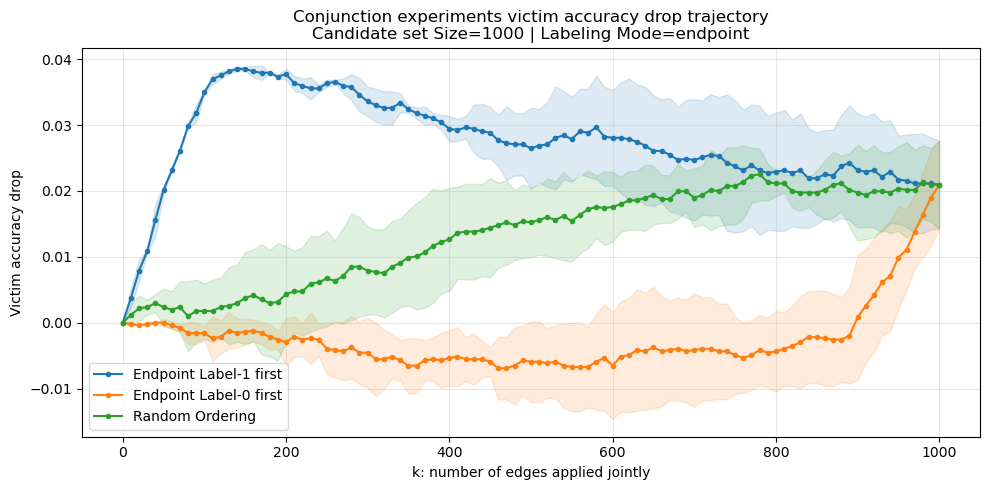

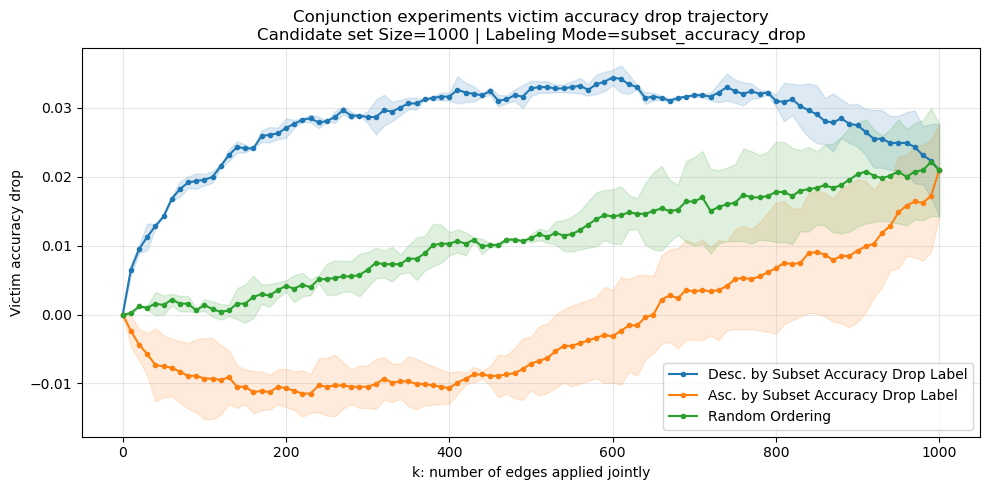

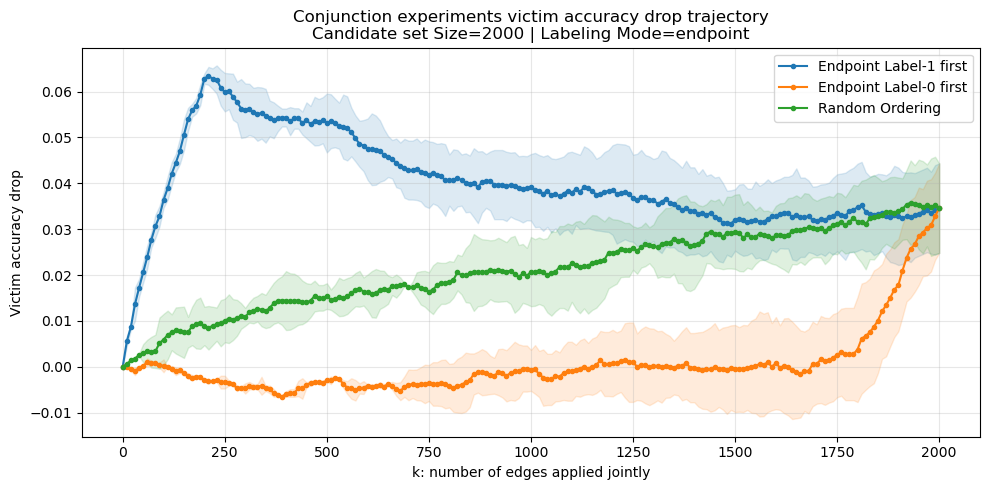

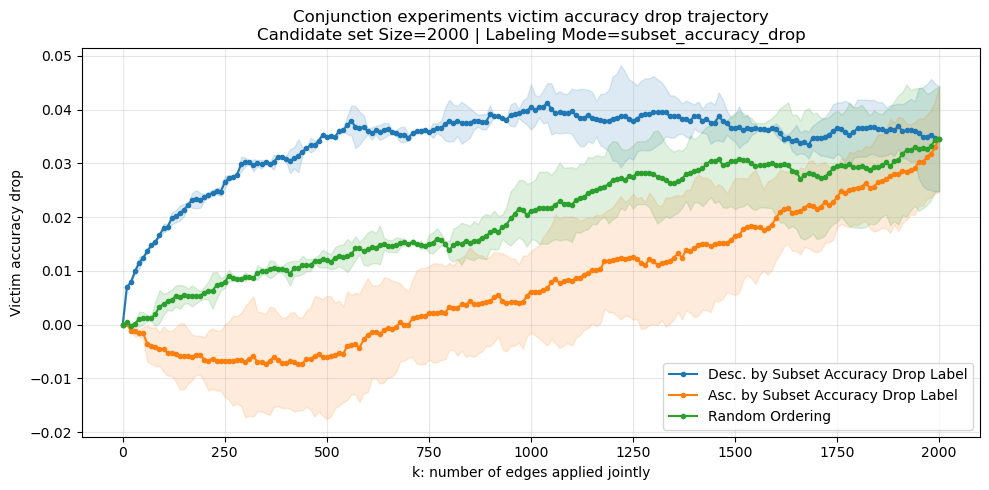

Saved conjunction experiment plots to: E:\Masterarbeit\AttackerGNN\extendedPlotting\final_runs\RQ2\rq2_conjunction_experiment\plots


In [8]:
# ============================================================
# Plot conjunction experiment trajectories
#
# One plot per:
#   candidate_set_size × scoring_mode
#
# y-axis:
#   victim_accuracy_drop
#
# lines:
#   descending / ascending / random
#
# shading:
#   ±1 standard deviation across seeds
# ============================================================

CONJUNCTION_PLOT_DIR = RQ2_CONJUNCTION_EXP_OUT_DIR / "plots"
CONJUNCTION_PLOT_DIR.mkdir(parents=True, exist_ok=True)

# Mean and standard deviation across all seeds.
conjunction_plot_df = (
    rq2_conjunction_accuracy_raw
    .groupby(["candidate_set_size", "scoring_mode", "ordering", "k"], dropna=False)
    .agg(
        victim_accuracy_drop_mean=("victim_accuracy_drop", "mean"),
        victim_accuracy_drop_std=("victim_accuracy_drop", "std"),
        n_seeds=("seed", "nunique"),
    )
    .reset_index()
)

ordering_labels = {
    "endpoint_label_desc": "Endpoint Label-1 first",
    "endpoint_label_asc": "Endpoint Label-0 first",
    "subset_score_desc": "Desc. by Subset Accuracy Drop Label",
    "subset_score_asc": "Asc. by Subset Accuracy Drop Label",
    "random": "Random Ordering",
}

# ------------------------------------------------------------
# Plot one figure per candidate_set_size × scoring_mode
# ------------------------------------------------------------

for (candidate_set_size, scoring_mode), frame in conjunction_plot_df.groupby(
    ["candidate_set_size", "scoring_mode"],
    dropna=False,
):

    if scoring_mode == "endpoint":
        ordering_sequence = [
            "endpoint_label_desc",
            "endpoint_label_asc",
            "random",
        ]
    elif scoring_mode == "subset_accuracy_drop":
        ordering_sequence = [
            "subset_score_desc",
            "subset_score_asc",
            "random",
        ]
    else:
        continue

    fig, ax = plt.subplots(figsize=(10, 5))

    for ordering in ordering_sequence:

        ordering_df = frame[frame["ordering"] == ordering].copy()
        ordering_df = ordering_df.sort_values("k")

        x = ordering_df["k"].to_numpy(dtype=float)
        mean = ordering_df["victim_accuracy_drop_mean"].to_numpy(dtype=float)
        std = ordering_df["victim_accuracy_drop_std"].to_numpy(dtype=float)

        line = ax.plot(
            x,
            mean,
            marker="o",
            markersize=3,
            label=ordering_labels.get(ordering, ordering),
        )[0]

        ax.fill_between(
            x,
            mean - std,
            mean + std,
            alpha=0.15,
            color=line.get_color(),
        )

    ax.set_xlabel("k: number of edges applied jointly")
    ax.set_ylabel("Victim accuracy drop")
    ax.set_title(
        f"Conjunction experiments victim accuracy drop trajectory\n"
        f"Candidate set Size={candidate_set_size} | Labeling Mode={scoring_mode}"
    )

    ax.grid(True, alpha=0.3)
    ax.legend()
    fig.tight_layout()

    safe_mode = "".join(
        c if c.isalnum() or c in "-_" else "_"
        for c in str(scoring_mode)
    )

    fig.savefig(
        CONJUNCTION_PLOT_DIR
        / f"conjunction_experiment__candN-{candidate_set_size}_{DATASET}_{safe_mode}.png",
        dpi=200,
        bbox_inches="tight",
    )

    plt.show()


print("Saved conjunction experiment plots to:", CONJUNCTION_PLOT_DIR.resolve())

## Experiment 3 — Label-Informed PR-BCD Block Initialization

The final RQ2 experiment evaluates whether the two harmfulness objectives remain informative inside the PR-BCD optimization scheme.

This experiment tests the **PR-BCD usefulness** requirement.

For endpoint harmfulness, the initial PR-BCD blocks are constructed from:

- endpoint label-1 edges;
- endpoint label-0 edges;
- random candidate edges.

The label-0 group is subsampled to match the number of available label-1 candidates, so that the compared blocks have equal size.

For subset accuracy-drop harmfulness, the initial blocks contain:

- the highest-scoring $10\%$ of candidates;
- the lowest-scoring $10\%$ of candidates;
- an equally sized random candidate block.

Each initialized block is evaluated under two PR-BCD optimization regimes:

### Fixed block

Resampling is disabled. PR-BCD optimizes only the supplied initial candidate block.

### Resampling enabled

PR-BCD starts from the supplied initial block and subsequently applies the standard `WeightOnly` block-resampling procedure during the configured resampling phase.

The experiment therefore evaluates whether high-harmfulness candidate blocks produce stronger PR-BCD trajectories and final perturbation sets than low-harmfulness and random candidate blocks.

In [ ]:

RQ2_INITIAL_BLOCK_EXP_OUT_DIR = RQ2_OUT_DIR / "rq2_initial_block"
RQ2_INITIAL_BLOCK_EXP_OUT_DIR.mkdir(parents=True,exist_ok=True)

# Experiment Parameters
RQ2_BLOCK_SUBSET_EXTREME_FRACTION = 0.10

# PR-BCD Parameters
RQ2_BLOCK_ATTACK_BUDGET_FRACTION = 0.03
RQ2_BLOCK_EPOCHS = 100
RQ2_BLOCK_RESAMPLING_EPOCHS = 50 # Only when resampling is not disabled

# Helper functions
def _sample_random_edges_from_set(candidates, n, seed):
    rng = np.random.default_rng(seed)
    indices = rng.choice(len(candidates), size=n, replace=False)
    return [candidates[i] for i in indices]

# Run PR-BCD with initial blocks supplied
prbcd_initial_block_rows = []
prbcd_initial_block_metric_finals = []
for run in mining_runs:

    # Initial Block construction required variables
    seed = run["seed"]
    candidate_set_size = run["candidate_set_size"]
    scoring_mode = run["scoring_mode"]
    candidates = list(run["candidates"])

    # PR-BCD required variables
    context = run["context"]
    graph = context["graph"]
    n_nodes = context["n_nodes"]
    n_edges = context["n_edges_undirected"]
    n_possible_edges = context["n_edges_possible"]
    attack_budget = max(1, round(RQ2_BLOCK_ATTACK_BUDGET_FRACTION * n_edges))
    fine_tune_epochs = RQ2_BLOCK_EPOCHS - RQ2_BLOCK_RESAMPLING_EPOCHS

    # Build PR-BCD blocks for both labeling objectives
    if scoring_mode == "endpoint":
        labels = run["labels_changed"].detach().cpu().numpy()
        group_harmful = [
            candidate
            for candidate, label in zip(candidates, labels)
            if label > 0.5
        ]
        group_nonharmful = [
            candidate
            for candidate, label in zip(candidates, labels)
            if label < 0.5
        ]
        block_size = len(group_harmful)
        if len(group_nonharmful) < block_size:
            raise ValueError(
                f"Not enough group_nonharmful candidates for seed={seed}, "
                f"size={candidate_set_size}."
            )
        blocks = {
            "group_harmful": group_harmful,
            "group_nonharmful": _sample_random_edges_from_set(
                group_nonharmful,
                block_size,
                seed,
            ),
        }

    else:
        scores = np.asarray(run["labels_changed"], dtype=float)
        block_size = int(np.floor(RQ2_BLOCK_SUBSET_EXTREME_FRACTION * len(candidates)))
        order = np.argsort(scores)
        blocks = {
            "group_nonharmful": [
                candidates[i]
                for i in order[:block_size]
            ],
            "group_harmful": [
                candidates[i]
                for i in order[-block_size:]
            ],
        }

    # From initial PR-BCD implementation.
    if block_size <= attack_budget:
        raise ValueError(
            f"block_size={block_size} must be larger "
            f"than attack_budget={attack_budget}."
        )

    # Convert blocks to linear ids as in original PR-BCD search space.
    block_as_linear_ids = {block_name: _candidates_to_linear_ids(block_candidates, n_nodes)
        for block_name, block_candidates in blocks.items()
    }

    # Sample random edges like PR-BCD random block sampling
    # Guarantees unique edges and consistent block size
    block_as_linear_ids["group_random"] = torch.randperm(n_possible_edges)[:block_size]

    # Run PR-BCD for harmful, nonharmful and random blocks
    for block_name, linear_ids in block_as_linear_ids.items():
        for resampling_enabled in [True, False]:

            # Pass attack parameters and blocks
            attack_params = {
                "block_size": block_size,
                "epochs": RQ2_BLOCK_EPOCHS,
                "fine_tune_epochs": fine_tune_epochs,
                "with_early_stopping": False,
                "keep_heuristic": "WeightOnly",
                "loss_type": "tanhMargin",
                "initial_block_label": block_name,
                "initial_block_linear_ids": linear_ids,
                "resampling_enabled": resampling_enabled,
                "attack_sampling_seed": seed,
                "block_diagnostics_enabled": True,
            }

            print(
                f"PRBCD | seed={seed} | label_type={scoring_mode}"
                f"Candidate set size={candidate_set_size} | "
                f"block={block_name} | resampling={resampling_enabled}"
            )

            # Run PR-BCD with initial blocks
            result = experiment_global_attack_direct.run(
                graph=graph,
                data_dir="./data",
                dataset=DATASET,
                attack="PRBCD",
                attack_params=attack_params,
                selector_params={},
                epsilons=[RQ2_BLOCK_ATTACK_BUDGET_FRACTION],
                binary_attr=False,
                make_undirected=True,
                seed=seed,
                artifact_dir="cache",
                pert_adj_storage_type="evasion_global_adj",
                pert_attr_storage_type="evasion_global_attr",
                model_label=MODEL_LABEL,
                model_storage_type="demo_custom_split", # Model storage is bypassed.
                device="cpu",
                data_device="cpu",
                debug_level="info",
                semi=True,
                use_cert="none",
            )

            # Extract accuracy trajectories from PR-BCD results
            accuracy_values = result["attack_statistics"]["accuracy"]
            accuracies = _to_numpy(accuracy_values)

            # Calculate extra results
            maximum_accuracy_drop = (run["clean_accuracy"] - accuracies).max()
            final_results = result.get("results", [])
            final_accuracy = float(torch.as_tensor(final_results[0]["accuracy"]).item())
            final_accuracy_drop = run["clean_accuracy"] - final_accuracy

            # Extract block diagnostics for comparison of final perturbations to initial block
            diagnostics = result["attack_statistics"]["block_diagnostics"]
            initial_block_ids = diagnostics["initial_block"]
            final_perturbation_ids = diagnostics["final_linear_ids"]

            # Extract the fraction of edges present in the block at a specific epoch
            fraction_retained_by_epoch = {-1: 1,}
            for epoch, epoch_block_ids in diagnostics["epoch_blocks"].items():
                fraction_retained_by_epoch[epoch] = torch.isin(initial_block_ids, epoch_block_ids).sum().item() / initial_block_ids.numel()

            # Fraction of initial edges contained in final perturbation set
            final_initial_fraction = torch.isin(final_perturbation_ids, initial_block_ids).sum().item() / final_perturbation_ids.numel()

            prbcd_initial_block_metric_finals.append({
                "seed": seed,
                "candidate_set_size": candidate_set_size,
                "scoring_mode": scoring_mode,
                "resampling_enabled": resampling_enabled,
                "block": block_name,
                "block_size": block_size,
                "final_accuracy_drop": final_accuracy_drop,
                "maximum_accuracy_drop": maximum_accuracy_drop,
                "final_initial_fraction": final_initial_fraction,
            })

            for i, victim_accuracy in enumerate(accuracies):
                prbcd_epoch = i-1
                prbcd_initial_block_rows.append({
                    "seed": seed,
                    "candidate_set_size": candidate_set_size,
                    "scoring_mode": scoring_mode,
                    "resampling_enabled": resampling_enabled,
                    "block": block_name,
                    "block_size": block_size,
                    "prbcd_epoch": prbcd_epoch,
                    "accuracy_drop": run["clean_accuracy"] - victim_accuracy,
                    "fraction_retained": fraction_retained_by_epoch[prbcd_epoch],
                })


rq2_prbcd_block_accuracy_raw = pd.DataFrame(prbcd_initial_block_rows)
display(rq2_prbcd_block_accuracy_raw)

rq2_prbcd_block_finals_raw = pd.DataFrame(prbcd_initial_block_metric_finals)
display(rq2_prbcd_block_finals_raw)

# Average repetitions within each seed first
rq2_prbcd_block_finals_per_seed = (
    rq2_prbcd_block_finals_raw
    .groupby([
        "seed",
        "candidate_set_size",
        "scoring_mode",
        "resampling_enabled",
        "block",
    ], as_index=False)[["final_accuracy_drop", "maximum_accuracy_drop", "final_initial_fraction"]]
    .mean()
)

rq2_prbcd_final_initial_utilization = (
    rq2_prbcd_block_finals_per_seed
    .query("resampling_enabled == True")
    .groupby([
        "candidate_set_size",
        "scoring_mode",
        "block",
    ])["final_initial_fraction"]
    .agg(["mean", "std"])
    .reset_index()
)
display(rq2_prbcd_final_initial_utilization)

# Put harmful nonharmful and random next to each other
rq2_prbcd_block_finals_pivot = (
    rq2_prbcd_block_finals_per_seed
    .pivot(index=["seed", "candidate_set_size", "scoring_mode", "resampling_enabled"],
        columns="block",
        values=["final_accuracy_drop","maximum_accuracy_drop"],
    )
)

# Add differences for later comparison
for metric in ["final_accuracy_drop", "maximum_accuracy_drop"]:
    rq2_prbcd_block_finals_pivot[(metric, "high_minus_low")] = (
            rq2_prbcd_block_finals_pivot[(metric, "group_harmful")]
            - rq2_prbcd_block_finals_pivot[(metric, "group_nonharmful")]
    )

    rq2_prbcd_block_finals_pivot[(metric, "high_minus_random")] = (
            rq2_prbcd_block_finals_pivot[(metric, "group_harmful")]
            - rq2_prbcd_block_finals_pivot[(metric, "group_random")]
    )

rq2_prbcd_block_finals_pivot = (
    rq2_prbcd_block_finals_pivot
    .reset_index()
)

rq2_prbcd_block_finals_results = (
    rq2_prbcd_block_finals_pivot
    .drop(columns="seed")
    .groupby([
        "candidate_set_size",
        "scoring_mode",
        "resampling_enabled",
    ])
    .agg(["mean", "std"])
    .reset_index()
)

display(rq2_prbcd_block_finals_results)

rq2_prbcd_block_accuracy_results = (
    rq2_prbcd_block_accuracy_raw
    .drop(columns="seed")
    .groupby([
        "candidate_set_size",
        "scoring_mode",
        "block",
        "resampling_enabled",
        "prbcd_epoch",
    ])
    .agg(["mean", "std"])
    .reset_index()
)

rq2_prbcd_block_accuracy_results.columns = [
    "_".join(str(part) for part in column if str(part))
    if isinstance(column, tuple)
    else column
    for column in rq2_prbcd_block_accuracy_results.columns
]

rq2_prbcd_block_finals_results.columns = [
    "_".join(str(part) for part in column if str(part))
    if isinstance(column, tuple)
    else column
    for column in rq2_prbcd_block_finals_results.columns
]

display(rq2_prbcd_block_accuracy_results)

rq2_prbcd_final_initial_utilization.to_csv(
    RQ2_INITIAL_BLOCK_EXP_OUT_DIR
    / (
        f"rq2_final_initial_block_utilization_{DATASET}"
        f"_candidates{'-'.join(map(str, CANDIDATE_SET_SIZES))}"
        f"_seeds{'-'.join(map(str, SEEDS))}.csv"
    ),
    index=False,
)

rq2_prbcd_block_finals_results.to_csv(
    RQ2_INITIAL_BLOCK_EXP_OUT_DIR
    / (
        f"rq2_initial_block_metrics_{DATASET}"
        f"_candidates{'-'.join(map(str, CANDIDATE_SET_SIZES))}"
        f"_seeds{'-'.join(map(str, SEEDS))}.csv"
    ),
    index=False,
)

rq2_prbcd_block_accuracy_results.to_csv(
    RQ2_INITIAL_BLOCK_EXP_OUT_DIR
    / (
        f"rq2_initial_block_experiment_{DATASET}"
        f"_candidates{'-'.join(map(str, CANDIDATE_SET_SIZES))}"
        f"_seeds{'-'.join(map(str, SEEDS))}.csv"
    ),
    index=False,
)

print(f"\nSaved to: {RQ2_INITIAL_BLOCK_EXP_OUT_DIR.resolve()}")

### Label-Informed PR-BCD Plots

The following plots visualize how the supplied initial candidate blocks influence PR-BCD optimization.

### Accuracy-Drop Trajectories

The first plots show the development of victim accuracy reduction over PR-BCD optimization epochs.

- **x-axis:** PR-BCD optimization epoch.
- **y-axis:** accuracy reduction relative to the clean victim model.
- **lines:** high-harmfulness, low-harmfulness, and random initial block.
- **separate conditions:** fixed-block PR-BCD and PR-BCD with resampling.
- **shaded regions:** one sample standard deviation across victim-model seeds.

The plots therefore show whether harmfulness-informed initialization improves the attack trajectory and whether this advantage persists once standard PR-BCD resampling is enabled.

### Initial-Block Retention

For resampling-enabled runs, the second set of plots shows how much of the supplied initial block remains active during optimization.

- **x-axis:** PR-BCD optimization epoch.
- **y-axis:** fraction of the initial block still contained in the current PR-BCD block.
- **lines:** high-harmfulness, low-harmfulness, and random initialization.
- **shaded regions:** one sample standard deviation across victim-model seeds.

These plots indicate how quickly the different initial candidate groups are removed by the `WeightOnly` resampling procedure and whether high-harmfulness candidates are retained more strongly during optimization.

The accompanying result tables summarize the corresponding final and maximum accuracy reductions as well as the fraction of final discrete perturbations that originate from the supplied initial block.

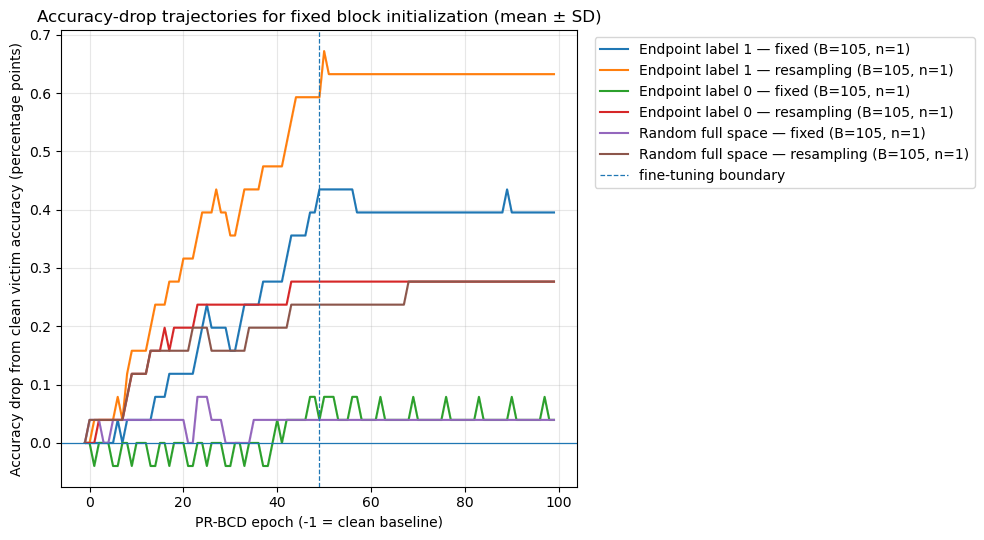

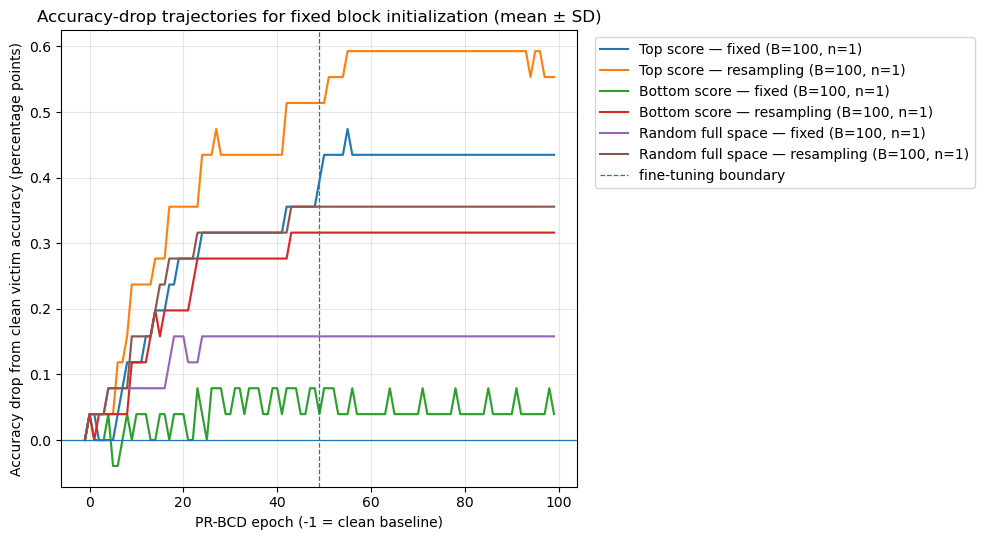

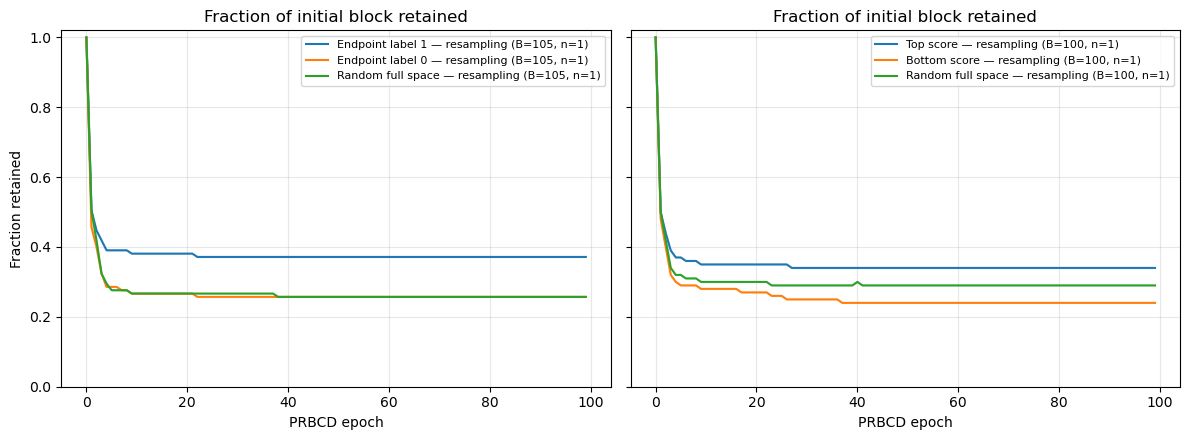

In [10]:

RQ2_INITIAL_BLOCK_PLOT_DIR = RQ2_INITIAL_BLOCK_EXP_OUT_DIR / "plots"
RQ2_INITIAL_BLOCK_PLOT_DIR.mkdir(parents=True, exist_ok=True)

# Mean and standard deviation across seeds
trajectory_summary = (
    rq2_prbcd_block_accuracy_raw
    .groupby([
        "candidate_set_size",
        "scoring_mode",
        "block",
        "resampling_enabled",
        "prbcd_epoch",
    ])["accuracy_drop"]
    .agg(["mean", "std", "count"])
    .reset_index()
)

# Plot Accuracy drop trajectory

for scoring_mode in ["endpoint", "subset_accuracy_drop"]:
    frame = trajectory_summary[trajectory_summary["scoring_mode"] == scoring_mode]

    for candidate_set_size, size_df in frame.groupby("candidate_set_size"):
        fig, ax = plt.subplots(figsize=(10, 5.5))

        for (block, resampling_enabled), condition_df in size_df.groupby([
            "block",
            "resampling_enabled",
        ]):

            condition_df = condition_df.sort_values("prbcd_epoch")

            if scoring_mode == "endpoint":
                block_label = {
                    "group_harmful": "Endpoint label 1",
                    "group_nonharmful": "Endpoint label 0",
                    "group_random": "Random full space",
                }[block]
            else:
                block_label = {
                    "group_harmful": "Top score",
                    "group_nonharmful": "Bottom score",
                    "group_random": "Random full space",
                }[block]

            resampling_label = (
                "resampling"
                if resampling_enabled
                else "fixed"
            )

            block_size = int(
                rq2_prbcd_block_accuracy_raw.loc[
                    (rq2_prbcd_block_accuracy_raw["candidate_set_size"] == candidate_set_size)
                    & (rq2_prbcd_block_accuracy_raw["scoring_mode"] == scoring_mode)
                    & (rq2_prbcd_block_accuracy_raw["block"] == block),
                    "block_size",
                ].iloc[0]
            )

            n_seeds = int(condition_df["count"].max())

            label = (
                f"{block_label} — {resampling_label} "
                f"(B={block_size}, n={n_seeds})"
            )

            x = condition_df["prbcd_epoch"].to_numpy()
            mean = condition_df["mean"].to_numpy() * 100
            std = condition_df["std"].fillna(0).to_numpy() * 100

            line = ax.plot(
                x,
                mean,
                label=label,
            )[0]

            ax.fill_between(
                x,
                mean - std,
                mean + std,
                alpha=0.15,
                color=line.get_color(),
            )

        ax.axvline(RQ2_BLOCK_RESAMPLING_EPOCHS - 1, linestyle="--", linewidth=0.9, label="fine-tuning boundary",)

        ax.axhline(0, linewidth=0.9)

        ax.set_xlabel("PR-BCD epoch (-1 = clean baseline)")
        ax.set_ylabel("Accuracy drop from clean victim accuracy ""(percentage points)")
        ax.set_title("Accuracy drop trajectories for fixed block initialization (mean ± SD)")

        ax.grid(True, alpha=0.3)
        ax.legend(bbox_to_anchor=(1.02, 1), loc="upper left")
        plot_path = (
            RQ2_INITIAL_BLOCK_PLOT_DIR
            / f"rq2_initial_block_{DATASET}_{scoring_mode}_candN-{candidate_set_size}.png"
        )
        fig.savefig(plot_path, dpi=300, bbox_inches="tight")
        fig.tight_layout()
        plt.show()



#Plot fraction of initial PRBCD block retained

# First average repetitions within each seed
retention_per_seed = (
    rq2_prbcd_block_accuracy_raw
    .query("resampling_enabled == True")
    .groupby([
        "seed",
        "candidate_set_size",
        "scoring_mode",
        "block",
        "prbcd_epoch",
    ], as_index=False)["fraction_retained"]
    .mean()
)

# Then mean and SD across seeds
retention_summary = (
    retention_per_seed
    .groupby([
        "candidate_set_size",
        "scoring_mode",
        "block",
        "prbcd_epoch",
    ])["fraction_retained"]
    .agg(["mean", "std", "count"])
    .reset_index()
)

# Plot retention plot for each candidate set size and label mode.
for candidate_set_size, size_df in retention_summary.groupby("candidate_set_size"):

    fig, axes = plt.subplots(1, 2, figsize=(12, 4.5), sharey=True)

    for ax, scoring_mode in zip(axes, ["endpoint", "subset_accuracy_drop"]):

        frame = size_df[size_df["scoring_mode"] == scoring_mode]
        for block, condition_df in frame.groupby("block"):
            condition_df = condition_df.sort_values("prbcd_epoch")

            # Optional: remove -1 so epoch 0 is the first displayed point
            condition_df = condition_df[condition_df["prbcd_epoch"] >= 0]

            if scoring_mode == "endpoint":
                block_label = {
                    "group_harmful": "Endpoint label 1",
                    "group_nonharmful": "Endpoint label 0",
                    "group_random": "Random full space",
                }[block]

            else:
                block_label = {
                    "group_harmful": "Top score",
                    "group_nonharmful": "Bottom score",
                    "group_random": "Random full space",
                }[block]

            block_size = int(
                rq2_prbcd_block_accuracy_raw.loc[
                    (rq2_prbcd_block_accuracy_raw["candidate_set_size"] == candidate_set_size)
                    & (rq2_prbcd_block_accuracy_raw["scoring_mode"] == scoring_mode)
                    & (rq2_prbcd_block_accuracy_raw["block"] == block),
                    "block_size",
                ].iloc[0]
            )

            n_seeds = int(condition_df["count"].max())

            x = condition_df["prbcd_epoch"].to_numpy()
            mean = condition_df["mean"].to_numpy()
            std = condition_df["std"].fillna(0).to_numpy()

            line = ax.plot(x, mean, label=f"{block_label} — resampling " f"(B={block_size}, s={n_seeds})",)[0]
            ax.fill_between(x, mean - std, mean + std, alpha=0.15, color=line.get_color())

        ax.set_title("Fraction of initial block retained")
        ax.set_xlabel("PRBCD epoch")
        ax.set_ylim(0, 1.02)

        ax.grid(True, alpha=0.3)
        ax.legend(loc="upper right", fontsize=8)

    axes[0].set_ylabel("Fraction retained")
    fig.tight_layout()

    plot_path = (
        RQ2_INITIAL_BLOCK_PLOT_DIR
        / (
            f"rq2_initial_block_retention_{DATASET}"
            f"_candN-{candidate_set_size}.png"
        )
    )

    fig.savefig(
        plot_path,
        dpi=300,
        bbox_inches="tight",
    )

    plt.show()

# Study 3 — Learned Candidate Selection

Study 3 treats the harmfulness information established in RQ2 as a supervised learning target.

A link prediction style selector is trained to assign harmfulness scores to candidate edge flips. Its usefulness is evaluated first through predictive performance and a standalone structural attack and subsequently as a component of PR-BCD block construction.

RQ3 asks:

> **To what extent can a link-prediction selector identify promising edge perturbations and improve the optimization trajectory and final outcome of the PR-BCD attack?**

Two hypotheses guide the experiments:

**H3.1:** A selector trained on harmfulness labels ranks harmful edge perturbations higher than non-harmful perturbations.

**H3.2:** Selector-guided block selection improves the PR-BCD attack trajectory and/or its final discrete perturbation set.

## Selector Training

A separate selector is trained for every victim-model seed, candidate-set size, and harmfulness objective.
The selector uses the clean graph and node attributes for message passing and receives the mined candidate edges from RQ2 as supervised edge-level examples.
The candidate set is divided into disjoint training, validation, and test partitions using a 70/15/15 split.
Endpoint-derived labels are treated as binary targets with positive-class weighting and label smoothing. Subset accuracy-drop labels are used directly as continuous targets in \([0,1]\).
The following cell trains the selectors, stores the selected model state for every mining run, and records the training and validation loss trajectories.

## Construct and persist the RQ3 source-subgraph candidate-mining sweep

This block now uses two independent cache layers:

1. **Candidate-pool cache:** stores the selected source nodes and the maximum
   sampled candidate pool once per victim seed, subgraph method, subgraph seed,
   and subgraph fraction.
2. **Label cache:** stores the expensive victim-query labels once per exact
   candidate size and scoring mode.

The sweep is resumable at configuration level: existing artifacts are loaded
individually, and only missing or explicitly invalidated configurations are
computed again. Progress is written continuously to a CSV manifest.


In [11]:

RQ3_SELECTOR_TRAINING_STATS_OUT_DIR = RQ3_OUT_DIR / "rq3_selector_training_stats"
RQ3_SELECTOR_TRAINING_STATS_OUT_DIR.mkdir(parents=True, exist_ok=True)

# For each candidate set and victim model, train a separate selector
selector_training_rows = []
for run in mining_runs:

    context = run["context"]
    device = context["attr"].device

    attr = context["attr"].to(device)
    edge_index_struct = context["edge_index"]

    # Construct edge index tensor of labeled candidate edges
    src = run["src"].long().to(device)
    dst = run["dst"].long().to(device)
    edge_index_lab = torch.stack([src, dst],dim=0)

    # Extract label vector for labeled candidate edges
    y_label = run["labels_changed"]
    print(
        f"\nTraining selector | "
        f"seed={run['seed']} | "
        f"candidates={run['candidate_set_size']} | "
        f"mode={run['scoring_mode']} | "
        f"training pairs={y_label.numel()}"
    )

    # Train Selector
    selector_model = train_selector(
        attr=attr,
        edge_index_struct=edge_index_struct,
        edge_index_lab=edge_index_lab,
        y_label=y_label,
        label_mode=run["scoring_mode"],
        device=device,
        num_epochs=SELECTOR_EPOCHS,
        hidden_dim=SELECTOR_HIDDEN,
        out_dim=SELECTOR_HIDDEN,
        lr=SELECTOR_LR,
        weight_decay=5e-4,
        early_stop=True,
        min_epochs_before_early_stop=300,
        patience=SELECTOR_PATIENCE,
        split_ratios=(0.70, 0.15, 0.15),
    )

    history = selector_model.training_history

    # Log Train and Validation Losses for later plotting
    for epoch, (train_loss, val_loss) in enumerate(
        zip(history["train_losses"], history["val_losses"]),
        start=1,
    ):
        selector_training_rows.append({
            "seed": run["seed"],
            "candidate_set_size": run["candidate_set_size"],
            "scoring_mode": run["scoring_mode"],
            "epoch": epoch,
            "train_loss": train_loss,
            "validation_loss": val_loss,
            "best_epoch": history["best_epoch"],
            "is_best_epoch": epoch == history["best_epoch"],
        })

    run["selector_model"] = selector_model

    run["edge_index_lab"] = edge_index_lab.detach().cpu()
    run["y_label"] = y_label.detach().cpu()

selector_training_stats_raw = pd.DataFrame(selector_training_rows)
display(selector_training_stats_raw)

# ------------------------------------------------------------
# Aggregate training trajectories across seeds
# ------------------------------------------------------------

selector_training_stats_results = (
    selector_training_stats_raw
    .groupby([
        "candidate_set_size",
        "scoring_mode",
        "epoch",
    ])
    .agg(
        train_loss_mean=("train_loss", "mean"),
        train_loss_std=("train_loss", "std"),
        validation_loss_mean=("validation_loss", "mean"),
        validation_loss_std=("validation_loss", "std"),
        n_seeds=("seed", "nunique"),
    )
    .reset_index()
)

display(selector_training_stats_results)

selector_training_stats_raw.to_csv(
    RQ3_SELECTOR_TRAINING_STATS_OUT_DIR
    / (
        f"rq3_selector_training_stats_raw_{DATASET}"
        f"_candidates{'-'.join(map(str, CANDIDATE_SET_SIZES))}"
        f"_seeds{'-'.join(map(str, SEEDS))}.csv"
    ),
    index=False,
)

selector_training_stats_results.to_csv(
    RQ3_SELECTOR_TRAINING_STATS_OUT_DIR
    / (
        f"rq3_selector_training_stats_{DATASET}"
        f"_candidates{'-'.join(map(str, CANDIDATE_SET_SIZES))}"
        f"_seeds{'-'.join(map(str, SEEDS))}.csv"
    ),
    index=False,
)

print(
    f"\nSaved selector training statistics to: "
    f"{RQ3_SELECTOR_TRAINING_STATS_OUT_DIR.resolve()}"
)



Training selector | seed=0 | candidates=1000 | mode=endpoint | training pairs=1000
[LP-GNN] Epoch 001/200 | train_loss=1.4444 | val_loss=1.2460 |  | early_stopping_metric=val_ap | current_best=0.1613 | patience_left=20 | new_best
[LP-GNN] Epoch 020/200 | train_loss=0.8110 | val_loss=1.2505 |  | early_stopping_metric=val_ap | current_best=0.2818 | patience_left=20
[LP-GNN] Epoch 040/200 | train_loss=0.7933 | val_loss=1.3328 |  | early_stopping_metric=val_ap | current_best=0.2818 | patience_left=19
Selector Training stopping at epoch 59. Best early_stopping_metric=0.2818 at epoch 17.

Training selector | seed=0 | candidates=1000 | mode=subset_accuracy_drop | training pairs=1000
[LP-GNN] Epoch 001/200 | train_loss=0.6929 | val_loss=0.6831 |  | early_stopping_metric=val_loss | current_best=0.6831 | patience_left=20 | new_best
[LP-GNN] Epoch 020/200 | train_loss=0.6736 | val_loss=0.6737 |  | early_stopping_metric=val_loss | current_best=0.6735 | patience_left=20
[LP-GNN] Epoch 040/200 | tr

,seed,candidate_set_size,scoring_mode,epoch,train_loss,validation_loss,best_epoch,is_best_epoch
0,0,1000,endpoint,1,1.444414,1.246009,17,False
1,0,1000,endpoint,2,1.425596,1.262934,17,False
2,0,1000,endpoint,3,1.400548,1.289213,17,False
3,0,1000,endpoint,4,1.374148,1.261007,17,False
4,0,1000,endpoint,5,1.325208,1.239959,17,False
...,...,...,...,...,...,...,...,...
501,1,2000,subset_accuracy_drop,55,0.688166,0.687349,3,False
502,1,2000,subset_accuracy_drop,56,0.688166,0.687349,3,False
503,1,2000,subset_accuracy_drop,57,0.688166,0.687349,3,False
504,1,2000,subset_accuracy_drop,58,0.688166,0.687348,3,False


,candidate_set_size,scoring_mode,epoch,train_loss_mean,train_loss_std,validation_loss_mean,validation_loss_std,n_seeds
0,1000,endpoint,1,1.423359,0.029776,1.241413,0.006499,2
1,1000,endpoint,2,1.408303,0.024456,1.256290,0.009395,2
2,1000,endpoint,3,1.387940,0.017831,1.277262,0.016901,2
3,1000,endpoint,4,1.363751,0.014703,1.249668,0.016036,2
4,1000,endpoint,5,1.318561,0.009401,1.225844,0.019961,2
...,...,...,...,...,...,...,...,...
265,2000,subset_accuracy_drop,55,0.683063,0.007216,0.682648,0.006649,2
266,2000,subset_accuracy_drop,56,0.683064,0.007215,0.682648,0.006648,2
267,2000,subset_accuracy_drop,57,0.683065,0.007214,0.682648,0.006648,2
268,2000,subset_accuracy_drop,58,0.683065,0.007214,0.682647,0.006649,2



Saved selector training statistics to: E:\Masterarbeit\AttackerGNN\extendedPlotting\final_runs\RQ3\rq3_selector_training_stats


## Evaluation of the Selector Scores

The first RQ3 evaluation investigates whether the trained selector generalizes to the held-out candidate test set \(\mathcal{C}_{\mathrm{test}}\). Because the two mining objectives produce different target types, separate evaluation statistics are used.

### Endpoint Harmfulness

For binary endpoint labels, the selector is evaluated primarily as a ranking model.

- **Average Precision (AP):** summarizes the precision-recall relationship over all possible score thresholds. Higher values indicate that label-\(1\) candidates are concentrated toward the top of the selector ranking.
- **ROC-AUC:** measures how often a randomly selected label-\(1\) candidate receives a higher selector score than a randomly selected label-\(0\) candidate.
- **Label-\(1\) rate:** fraction of positive endpoint labels in the held-out test set and therefore the baseline prevalence of harmful candidates.
- **Precision@10%:** fraction of label-\(1\) candidates among the highest scoring \(10\%\) of test candidates.
- **Lift@10%:** ratio between Precision@10% and the overall label-\(1\) rate. A lift above \(1\) indicates that the selector enriches harmful candidates within the highest-scoring part of its ranking.

### Subset Accuracy-Drop Harmfulness

For the continuous subset accuracy-drop labels, the selector is evaluated according to agreement between predicted scores and target scores.

- **Pearson correlation:** measures the linear relationship between predicted and target harmfulness scores.
- **Spearman correlation:** measures agreement between the predicted and target rankings.
- **\(R^2\):** measures how much of the variation in the target scores is explained by the selector predictions.
- **Target standard deviation:** describes the dispersion of the true subset accuracy-drop labels in the test set.
- **Prediction standard deviation:** describes the dispersion of the selector predictions and helps identify prediction collapse toward a nearly constant score.
- **NDCG@10%:** evaluates whether candidates with the highest true harmfulness scores are also concentrated near the top of the selector ranking, with greater importance assigned to higher-ranked positions.

All statistics are first computed separately for every victim-model seed. They are subsequently aggregated for each candidate-set size and harmfulness objective using their mean and sample standard deviation across seeds.

This evaluation provides the first test of **H3.1**, namely whether the selector assigns higher scores to more harmful candidate edge perturbations.

In [12]:

# Generated by ChatGPT 5.1
# Calculates pearson Correlation
def safe_correlation(x, y):
    x = np.asarray(x, dtype=float)
    y = np.asarray(y, dtype=float)

    if len(x) < 2:
        return np.nan

    if np.std(x) <= 1e-12 or np.std(y) <= 1e-12:
        return np.nan

    return float(np.corrcoef(x, y)[0, 1])

# Generated by ChatGPT 5.1
# Calculates Spearman Correlation
def spearman_correlation(x, y):
    x_rank = pd.Series(x).rank(method="average").to_numpy()
    y_rank = pd.Series(y).rank(method="average").to_numpy()

    return safe_correlation(x_rank, y_rank)

RQ3_SELECTOR_TEST_METRICS = RQ3_OUT_DIR / "rq3_selector_test_metrics"
RQ3_SELECTOR_TEST_METRICS.mkdir(parents=True, exist_ok=True)



selector_on_test_rows = []

for run in mining_runs:

    model = run["selector_model"]
    history = model.training_history
    device = next(model.parameters()).device
    context = run["context"]
    attr = context["attr"].to(device)

    edge_index_struct = context["edge_index"].long().to(device)
    src = run["src"].long().to(device)
    dst = run["dst"].long().to(device)
    candidates = torch.stack([src, dst], dim=0)

    y_labels = run["labels_changed"].float().to(device)
    test_idx = history["test_idx"].long().to(device)
    candidates_test = candidates[:, test_idx]
    y_labels_test = y_labels[test_idx].numpy()

    # Evaluate Selector on Test Set
    model.eval()
    with torch.no_grad():
        logits_test = model(attr, edge_index_struct, candidates_test).view(-1)
        scores_test = torch.sigmoid(logits_test)

    y_score = scores_test.detach().cpu().numpy()

    # Endpoint ranking evaluation for selector scores
    if run["scoring_mode"] == "endpoint":

        # Straight forward
        ap = average_precision_score(y_labels_test, y_score)
        roc_auc = roc_auc_score(y_labels_test, y_score)

        # take top 10% of scores for precision@k
        k = max(1, int(0.10 * len(y_score)))
        ranked_idx = np.argsort(y_score)[::-1].copy()
        top_k_idx = ranked_idx[:k]

        # Fraction of test candidates labeled 1
        label_1_rate = float(y_labels_test.mean())

        # Fraction of label-1 edges among the top-k scored candidates
        precision_at_k = float(y_labels_test[top_k_idx].mean())

        # Enrichment of top 10% compared to the actual rate
        lift_at_k = precision_at_k / label_1_rate

        row = {
            "seed": run["seed"],
            "candidate_set_size": run["candidate_set_size"],
            "scoring_mode": run["scoring_mode"],
            "test_pairs": len(y_labels_test),
            "label_1_rate": label_1_rate,
            "ap": float(ap),
            "roc_auc": float(roc_auc),
            "k": k,
            "precision_at_k": precision_at_k,
            "lift_at_k": float(lift_at_k),
        }


    # Regression metrics for subset accuracy drop scores
    else:
        # take top 10% of scores for NDCG@k
        k = max(1, int(0.10 * len(y_score)))

        ndcg_at_k = ndcg_score(y_labels_test.reshape(1, -1), y_score.reshape(1, -1), k=k)

        row = {
            "seed": run["seed"],
            "candidate_set_size": run["candidate_set_size"],
            "scoring_mode": run["scoring_mode"],
            "test_pairs": len(y_labels_test),
            "pearson": safe_correlation(y_labels_test, y_score),
            "spearman": spearman_correlation(y_labels_test, y_score),
            "r2": r2_score(y_labels_test, y_score),
            "target_sd": np.std(y_labels_test, ddof=0),
            "prediction_sd": np.std(y_score, ddof=0),
            "k": k,
            "ndcg_at_k": float(ndcg_at_k),
        }

    # Attach the results to the corresponding trained selector
    run["selector_test_results"] = row
    selector_on_test_rows.append(row)


# Log and save results
selector_metrics_on_test_raw = pd.DataFrame(selector_on_test_rows)

selector_metrics_on_test_results = (
    selector_metrics_on_test_raw
    .drop(columns="seed")
    .groupby(["candidate_set_size", "scoring_mode"])
    .agg(["mean", "std"])
    .reset_index()
)

selector_metrics_on_test_results.columns = [
    "_".join(str(part) for part in column if str(part))
    if isinstance(column, tuple)
    else column
    for column in selector_metrics_on_test_results.columns
]

selector_metrics_on_test_results.to_csv(
    RQ3_OUT_DIR
    / (
        f"rq3_diagnostic_statistics_{DATASET}"
        f"_candidates{'-'.join(map(str, CANDIDATE_SET_SIZES))}"
        f"_seeds{'-'.join(map(str, SEEDS))}.csv"
    ),
    index=False,
)

display(selector_metrics_on_test_results)

,candidate_set_size,scoring_mode,test_pairs_mean,test_pairs_std,label_1_rate_mean,label_1_rate_std,ap_mean,ap_std,roc_auc_mean,roc_auc_std,...,spearman_mean,spearman_std,r2_mean,r2_std,target_sd_mean,target_sd_std,prediction_sd_mean,prediction_sd_std,ndcg_at_k_mean,ndcg_at_k_std
0,1000,endpoint,150.0,0.0,0.106667,0.009428,0.274454,0.069719,0.651766,0.099049,...,NaN,NaN,NaN,NaN,NaN,NaN,NaN,NaN,NaN,NaN
1,1000,subset_accuracy_drop,150.0,0.0,NaN,NaN,NaN,NaN,NaN,NaN,...,0.081297,0.007259,0.005303,0.003798,0.12166,0.040693,0.007930,0.000177,0.612996,0.046327
2,2000,endpoint,300.0,0.0,0.100000,0.000000,0.178988,0.011855,0.645247,0.005151,...,NaN,NaN,NaN,NaN,NaN,NaN,NaN,NaN,NaN,NaN
3,2000,subset_accuracy_drop,300.0,0.0,NaN,NaN,NaN,NaN,NaN,NaN,...,0.045872,0.025687,-0.000574,0.001634,0.13575,0.001484,0.001672,0.000983,0.630898,0.066234


## Experiment — Selector Direct Structural Attack

The held-out selector metrics evaluate prediction quality on labeled candidate edges. This experiment subsequently tests whether the learned selector ranking itself provides a harmful structural perturbation signal.

It follows the direct cumulative structural attack introduced in RQ2, but replaces the mined-label ordering with an ordering induced by the selector scores.

A new candidate set is sampled independently from the complete possible edge universe. Every trained selector scores this same candidate set.

Two orderings are then evaluated:

$
\Pi^{\mathrm{sel}}_{\downarrow}
:
\quad
\text{highest selector scores first},
$

and a random control ordering

$
\Pi^{\mathrm{rand}}.
$

Starting from the clean graph, candidate edges are cumulatively flipped in batches of ten. Victim accuracy is evaluated after every cumulative perturbation step.

The experiment investigates **H3.1** beyond the held-out labeled examples and additionally probes whether the selector can serve as a standalone untargeted structural evasion attack.

In [19]:

# Setup parameters
BLOCK_STEP_SELECTOR_CONJUNCTION = 10

# New candidate pool used only for evaluating the trained selectors.
shared_cand_set_size = 10_000

# Same candidate pool for every mining run.
selector_conjunction_seed = 20

# Same random ordering for every mining run.
conjunction_random_ord_seed = 10

RQ3_SELECTOR_CONJUNCTION_OUT_DIR = RQ3_OUT_DIR / "rq3_selector_conjunction_experiment"
RQ3_SELECTOR_CONJUNCTION_OUT_DIR.mkdir(parents=True, exist_ok=True)

# ============================================================
# Sample shared oracle candidate pool
# ============================================================

# All mining runs operate on the same underlying dataset.
n_nodes = mining_runs[0]["context"]["n_nodes"]

shared_candidate_set = sample_random_candidates(n_nodes, shared_cand_set_size, seed=selector_conjunction_seed)
shared_candidates = list(shared_candidate_set)

rng = random.Random(conjunction_random_ord_seed)
rng.shuffle(shared_candidates)

shared_candidates_tensor = torch.tensor(shared_candidates, dtype=torch.long).t().contiguous()

# Run selector conjucntion experiment for all candidate sets and victim seeds
selector_conjunction_rows = []
for run_index, run in enumerate(mining_runs):

    seed = run["seed"]
    candidate_set_size = run["candidate_set_size"]
    label_mode = run["scoring_mode"]

    context = run["context"]
    edge_index_struct = context["edge_index"]
    attr = context["attr"]
    clean_adj = context["adj_matrix"].clone()
    victim_idx_test = context["idx_test"]
    victim_labels = context["labels"]
    victim_model = context["model"]
    victim_clean_acc = run["clean_accuracy"]

    selector = run["selector_model"]

    exists = np.array([bool(clean_adj[u, v] == 1) for u, v in shared_candidates])

    # Score conjunction candidate set once
    selector.eval()
    with torch.no_grad():
        selector_logits = selector(attr, edge_index_struct, shared_candidates_tensor)
        selector_scores = torch.sigmoid(selector_logits).view(-1)

    orders = {
        # Highest to lowest scoring edges.
        "selector_score_desc": np.argsort(-selector_scores),
        # shared_candidates is already shuffled.
        "random": np.arange(len(shared_candidates))
    }

    block_sizes = list(range(BLOCK_STEP_SELECTOR_CONJUNCTION,
                             shared_cand_set_size + 1,
                             BLOCK_STEP_SELECTOR_CONJUNCTION))

    # Ensures compatability with candidate sets where
    # shared_cand_set_size % BLOCK_STEP_SELECTOR_CONJUNCTION != 0
    if not block_sizes or block_sizes[-1] != shared_cand_set_size:
        block_sizes.append(shared_cand_set_size)

    for ordering_name, order in (orders.items()):
        # Reset adjacency
        adj = clean_adj.clone()
        previous_k = 0

        # Same as RQ2 :
        # Init first victim accuracy drop with 0.
        selector_conjunction_rows.append({
            "seed": seed,
            "candidate_set_size": candidate_set_size,
            "shared_cand_set_size": shared_cand_set_size,
            "label_mode": label_mode,
            "ordering":ordering_name,
            "k": 0,
            "victim_accuracy_drop": 0.0,
        })

        for k in tqdm(block_sizes, desc=(
                f"seed={seed}, "
                f"train_size={candidate_set_size}, "
                f"mode={label_mode}, "
                f"order={ordering_name}")):
            for candidate_index in (order[previous_k:k]):
                # Flip one candidate
                adj = _flip_candidate_sparse(adj, shared_candidates, exists, candidate_index)

            # Compute victim accuracy after cumulated flips
            victim_accuracy = accuracy(victim_model, attr, victim_labels, victim_idx_test, adj)

            # Compute accuracy drop after cumulated flips
            victim_accuracy_drop = victim_clean_acc - victim_accuracy

            selector_conjunction_rows.append({
                "seed": seed,
                "candidate_set_size": candidate_set_size,
                "shared_cand_set_size": shared_cand_set_size,
                "label_mode": label_mode,
                "ordering": ordering_name,
                "k": k,
                "victim_accuracy_drop": victim_accuracy_drop
            })
            previous_k = k


rq3_selector_conjunction_raw = pd.DataFrame(selector_conjunction_rows)
display(rq3_selector_conjunction_raw)

rq3_selector_conjunction_results = (
    rq3_selector_conjunction_raw
    .groupby(["candidate_set_size" ,"shared_cand_set_size", "label_mode", "ordering","k"],
        as_index=False,
    )
    .agg(
        victim_accuracy_drop_mean=("victim_accuracy_drop","mean"),
        victim_accuracy_drop_std=("victim_accuracy_drop","std"),
        n_seeds=("seed","nunique"),
    )
)
display(rq3_selector_conjunction_results)

candidate_sizes_string = "-".join(map(str, sorted({run["candidate_set_size"] for run in mining_runs})))
seed_string = "-".join(map(str, sorted({ run["seed"] for run in mining_runs})))

results_path = (RQ3_SELECTOR_CONJUNCTION_OUT_DIR
    / (
        f"rq3_selector_conjunction_{DATASET}"
        f"_traincandidates{candidate_sizes_string}"
        f"_seeds{seed_string}.csv"
    )
)

rq3_selector_conjunction_results.to_csv(results_path,index=False)

print(
    "Saved results to:",
    results_path.resolve(),
)

torch.Size([10000])



torch.Size([10000])



torch.Size([10000])



torch.Size([10000])



torch.Size([10000])


...


torch.Size([10000])



torch.Size([10000])


,seed,candidate_set_size,shared_cand_set_size,label_mode,ordering,k,victim_accuracy_drop
0,0,1000,10000,endpoint,selector_score_desc,0,0.000000
1,0,1000,10000,endpoint,selector_score_desc,10,0.001976
2,0,1000,10000,endpoint,selector_score_desc,20,0.002767
3,0,1000,10000,endpoint,selector_score_desc,30,0.003557
4,0,1000,10000,endpoint,selector_score_desc,40,0.004743
...,...,...,...,...,...,...,...
16011,1,2000,10000,subset_accuracy_drop,random,9960,0.056126
16012,1,2000,10000,subset_accuracy_drop,random,9970,0.056917
16013,1,2000,10000,subset_accuracy_drop,random,9980,0.057312
16014,1,2000,10000,subset_accuracy_drop,random,9990,0.057312


,candidate_set_size,shared_cand_set_size,label_mode,ordering,k,victim_accuracy_drop_mean,victim_accuracy_drop_std,n_seeds
0,1000,10000,endpoint,random,0,0.000000,0.000000,2
1,1000,10000,endpoint,random,10,0.000988,0.000280,2
2,1000,10000,endpoint,random,20,0.002174,0.000280,2
3,1000,10000,endpoint,random,30,0.001976,0.001118,2
4,1000,10000,endpoint,random,40,0.001581,0.001118,2
...,...,...,...,...,...,...,...,...
8003,2000,10000,subset_accuracy_drop,selector_score_desc,9960,0.052767,0.007546,2
8004,2000,10000,subset_accuracy_drop,selector_score_desc,9970,0.051779,0.008385,2
8005,2000,10000,subset_accuracy_drop,selector_score_desc,9980,0.051976,0.008105,2
8006,2000,10000,subset_accuracy_drop,selector_score_desc,9990,0.051976,0.008664,2


Saved results to: E:\Masterarbeit\AttackerGNN\extendedPlotting\final_runs\RQ3\rq3_selector_conjunction_experiment\rq3_selector_conjunction_cora_ml_traincandidates1000-2000_seeds0-1.csv


### Selector Direct Structural Attack Plots

The plots compare the cumulative victim-accuracy reduction obtained from the selector-induced ordering with the shared random ordering.

- **x-axis:** cumulative number of applied candidate edge flips.
- **y-axis:** victim accuracy reduction relative to the clean graph in percentage points.
- **selector curves:** descending selector-score ordering for selectors trained on different candidate-set sizes.
- **random curve:** shared random candidate ordering.
- **shaded region:** one sample standard deviation across victim-model seeds.

A selector curve above the random ordering indicates that the learned harmfulness ranking concentrates more damaging perturbations toward the beginning of the candidate ordering.

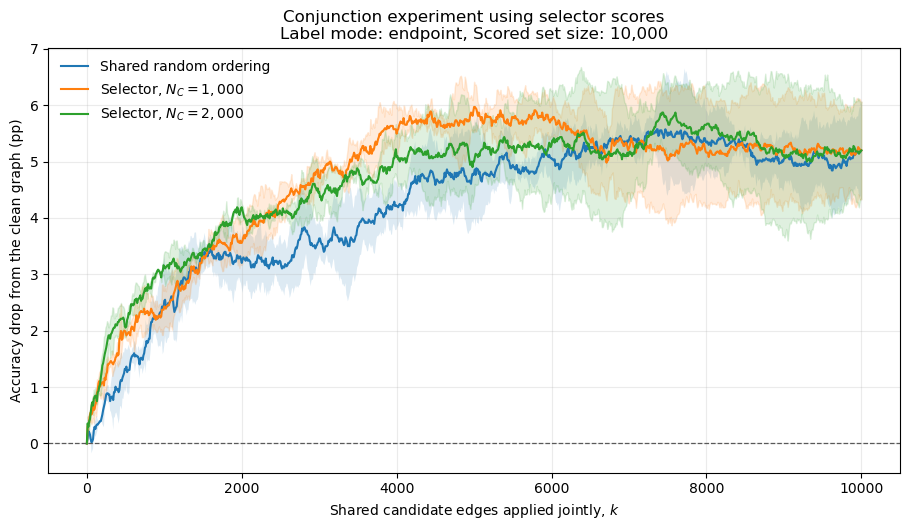

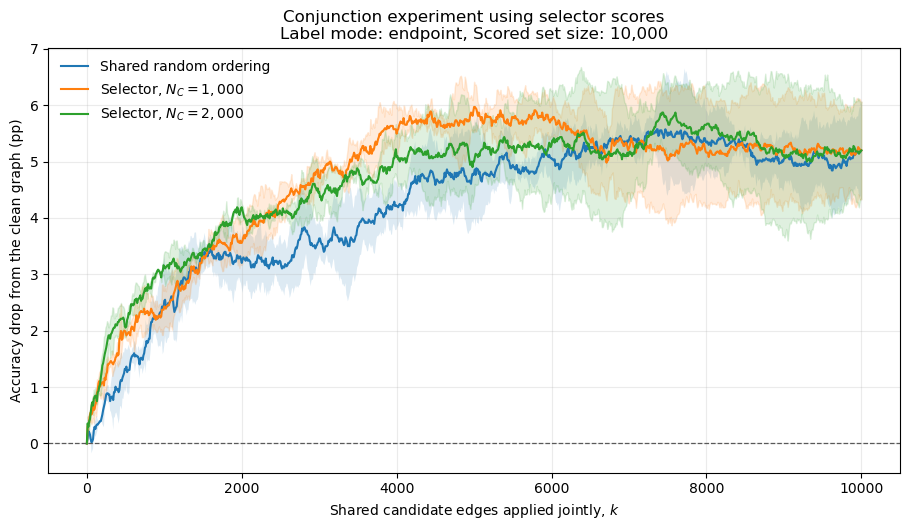

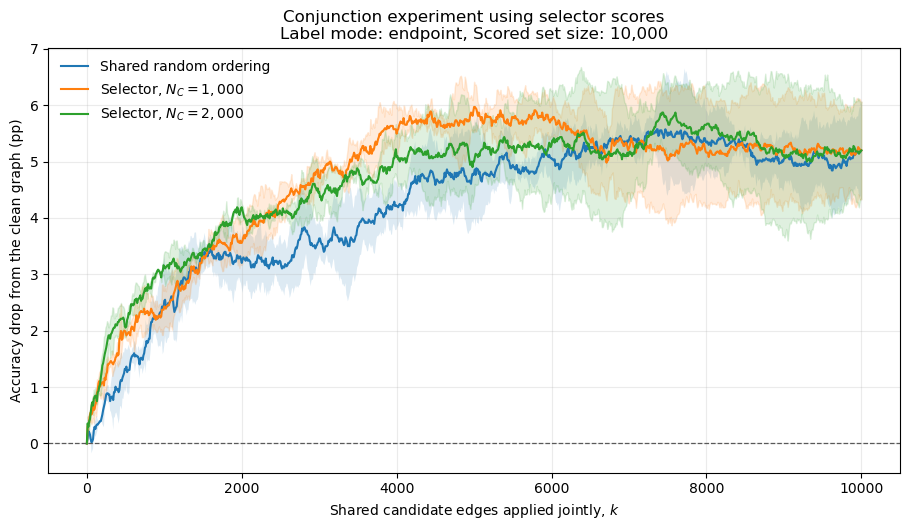

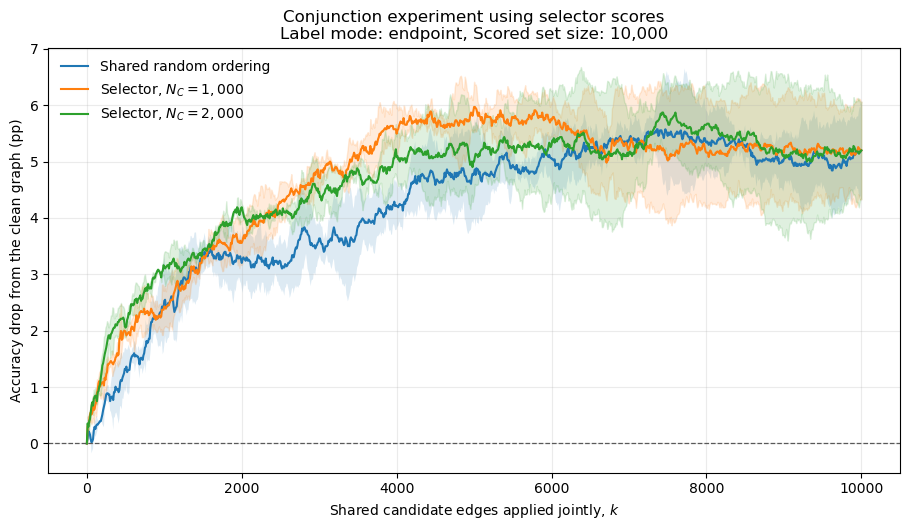

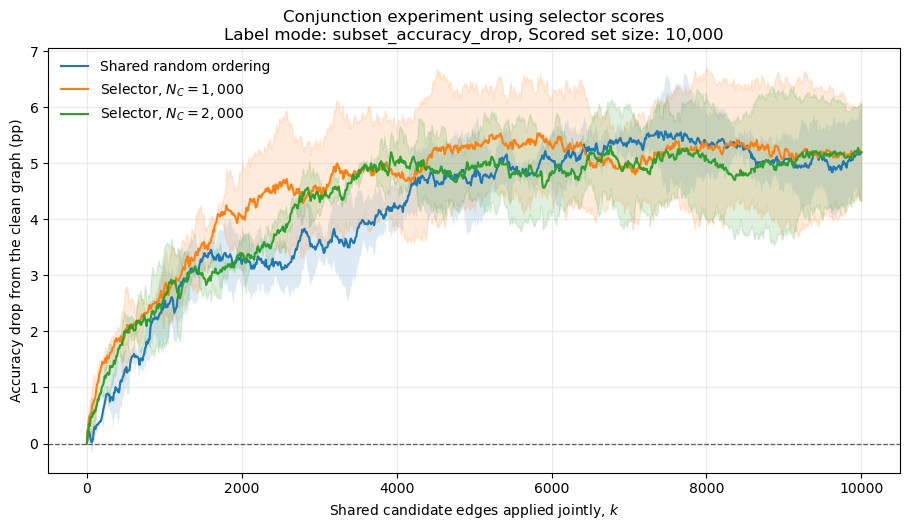

In [23]:

SELECTOR_CONJUNCTION_PLOT_DIR = RQ3_SELECTOR_CONJUNCTION_OUT_DIR / "plots"
SELECTOR_CONJUNCTION_PLOT_DIR.mkdir(parents=True,exist_ok=True)

for label_mode in ["endpoint", "subset_accuracy_drop"]:

    # Separate endpoint and subset accuracy drop dataframes
    plot_df = rq3_selector_conjunction_results[rq3_selector_conjunction_results["label_mode"] == label_mode]
    fig, ax = plt.subplots(figsize=(9.2, 5.4))

    # Plot random ordering once as it is indipendent of training set size
    # Fix generated by ChatGPT 5.1
    random_df = (
        plot_df[plot_df["ordering"] == "random"]
        .sort_values(["candidate_set_size", "k"])
        .drop_duplicates("k")
        .rename(columns={
                "victim_accuracy_drop_mean": "mean",
                "victim_accuracy_drop_std": "std",
            }
        )
    )

    # Fill in random curve
    ax.plot(random_df["k"], 100*random_df["mean"],label="Shared random ordering")
    ax.fill_between(
        random_df["k"],
        100*random_df["mean"] - 100*random_df["std"],
        100*random_df["mean"] + 100*random_df["std"],
        alpha=0.15,
    )

    # Construct dataframe for selector orderings
    selector_ordering_df = plot_df[plot_df["ordering"] == "selector_score_desc"]
    training_sizes = sorted(selector_ordering_df["candidate_set_size"].unique())

    # Add curve for every candidate set size
    for candidate_set_size in training_sizes:
        selector_line = selector_ordering_df[selector_ordering_df["candidate_set_size"] == candidate_set_size].sort_values("k")

        line = ax.plot(
            selector_line["k"],
            100*selector_line["victim_accuracy_drop_mean"],
            label=f"Selector, "rf"$N_{{C}}={candidate_set_size:,}$",
        )[0]

        ax.fill_between(
            selector_line["k"],
            100*selector_line["victim_accuracy_drop_mean"]
            - 100*selector_line["victim_accuracy_drop_std"],
            100*selector_line["victim_accuracy_drop_mean"]
            + 100*selector_line["victim_accuracy_drop_std"],
            alpha=0.15,
            color=line.get_color(),
        )


    shared_cand_set_size = plot_df["shared_cand_set_size"].iloc[0]

    ax.axhline(0, linestyle="--", linewidth=0.9, color="0.35",)
    ax.set_xlabel(r"Shared candidate edges applied jointly, $k$")
    ax.set_ylabel("Accuracy drop from the clean graph (pp)")
    ax.set_title(
        "Conjunction experiment using selector scores\n"
        f"Label mode: {label_mode}, "
        f"Scored set size: {shared_cand_set_size:,}"
    )

    ax.grid(True, alpha=0.25)
    ax.legend(frameon=False)
    fig.tight_layout()

    fig.savefig(SELECTOR_CONJUNCTION_PLOT_DIR / f"rq3_selector_conjunction_{DATASET}_{label_mode}_new.png", dpi=200, bbox_inches="tight",)
    plt.show()

## Selector-Guided PR-BCD: PSG-BCD

The final RQ3 experiment evaluates **H3.2** by integrating the trained selector directly into PR-BCD block construction.

Because standard PR-BCD repeatedly discards low-weight coordinates during the resampling phase, selector guidance is used both for initial block construction and for subsequent block refilling.

The resulting attack is referred to as **Projected Selector Guided Block Coordinate Descent (PSG-BCD)**.

### Selector-Guided Initial Block

Instead of sampling the initial PR-BCD block uniformly from the complete edge universe, candidate edge batches are sampled and scored by the trained selector. High-scoring candidates are retained until the required block size is reached.

### Selector-Guided Resampling

During the PR-BCD resampling phase, the `WeightOnly` heuristic still determines which current candidates are discarded. The removed coordinates are then replaced using newly sampled candidate edges ranked by the selector rather than by uniform random sampling.

Candidates that have already been considered can be excluded from later selector sampling.

### Evaluation

PSG-BCD is compared with standard PR-BCD under otherwise matched attack configurations.

The experiment records final attacked accuracy and the complete per-epoch attack trajectory, including victim accuracy, attack loss, perturbation weights above the numerical floor, and probability mass before and after projection.

Final and epoch-level quantities are aggregated across victim-model seeds using their mean and sample standard deviation.

Only endpoint-trained selectors are used for the PSG-BCD experiment because the subset accuracy-drop selector did not provide a sufficiently reliable ranking signal in the preceding RQ3 evaluations.

In [ ]:


PRBCD_BLOCK_SIZES = [5_000]
PRBCD_EPSILONS = [0.05]

PRBCD_USE_CERTS = ["none", "accuracy_drop_selector_with_resampling"]

PRBCD_PARAMS = {
    "epochs": 150,
    "fine_tune_epochs": 100,
    "keep_heuristic": "WeightOnly",
    "do_synchronize": True,
    "loss_type": "tanhMargin",
}

PRBCD_SELECTOR_PARAMS = {
    "tau": 0.8,
    "score_batch_size": 1_000,
    "max_sampling_tries": 2_000_000,
    "top_k_per_batch": 100,
}

In [ ]:

# PR-BCD and PSG-BCD shared setup
MODEL_STORAGE_TYPE = "demo_custom_split"

ARTIFACT_DIR = "cache"
PERT_ADJ_STORAGE_TYPE = "evasion_global_adj"
PERT_ATTR_STORAGE_TYPE = "evasion_global_attr"

RQ3_GUIDED_PRBCD_OUT_DIR = (RQ3_OUT_DIR / "rq3_guided_prbcd")
RQ3_GUIDED_PRBCD_OUT_DIR.mkdir(parents=True, exist_ok=True)

SUMMARY_PATH = (
    RQ3_GUIDED_PRBCD_OUT_DIR
    / f"rq3_guided_prbcd_summary_{DATASET}.csv"
)

EPOCHS_PATH = (
    RQ3_GUIDED_PRBCD_OUT_DIR
    / f"rq3_guided_prbcd_epochs_{DATASET}.csv"
)


graph_sparse = load_and_standardize(f"data/{DATASET}.npz")
print(
    "Graph:",
    f"nodes={graph_sparse.attr_matrix.shape[0]}",
    f"features={graph_sparse.attr_matrix.shape[1]}",
    f"directed_edges={graph_sparse.adj_matrix.nnz}",
)

summary_rows = []
epoch_rows = []

# Total runs for logging
total_runs = (len(mining_runs) * len(PRBCD_BLOCK_SIZES) * len(PRBCD_EPSILONS) * len(PRBCD_USE_CERTS))

# Define sweep to avoid huge for loop
sweep = product(mining_runs, PRBCD_BLOCK_SIZES, PRBCD_EPSILONS, PRBCD_USE_CERTS)

for run_index, (mining_run, block_size, epsilon, use_cert) in enumerate(sweep, start=1):

    seed = mining_run["seed"]
    candidate_set_size = mining_run["candidate_set_size"]
    scoring_mode = mining_run["scoring_mode"]
    selector_model = mining_run["selector_model"] if use_cert != "none" else None

    # Skip all subset accuracy drop runs
    if scoring_mode == "subset_accuracy_drop":
        continue

    attack_params = {
        **PRBCD_PARAMS,
        "block_size": block_size,
        "lp_model": selector_model,
    }

    print("=" * 80)
    print(f"Run {run_index}/{total_runs}")
    print(
        f"seed={seed} | "
        f"candidate_set_size={candidate_set_size} | "
        f"scoring_mode={scoring_mode} | "
        f"block_size={block_size} | "
        f"epsilon={epsilon} | "
        f"use_cert={use_cert}"
    )

    # Delete old PR-BCD perturbation caches
    delete_pert_files_and_folders(
        cache_dir=ARTIFACT_DIR,
        pert_adj_storage_type=PERT_ADJ_STORAGE_TYPE,
        pert_attr_storage_type=PERT_ATTR_STORAGE_TYPE,
    )

    # PR-BCD / PSG-BCD
    start = timer()
    result = None
    try:
        result = experiment_global_attack_direct.run(
            graph=graph_sparse,
            data_dir="./data",
            dataset=DATASET,
            attack="PRBCD",
            attack_params=attack_params,
            selector_params=PRBCD_SELECTOR_PARAMS,
            epsilons=[epsilon],
            binary_attr=False,
            make_undirected=True,
            seed=seed,
            artifact_dir=ARTIFACT_DIR,
            pert_adj_storage_type=PERT_ADJ_STORAGE_TYPE,
            pert_attr_storage_type=PERT_ATTR_STORAGE_TYPE,
            model_label=MODEL_LABEL,
            model_storage_type=MODEL_STORAGE_TYPE,
            device="cpu",
            data_device="cpu",
            debug_level="info",
            semi=True,
            use_cert=use_cert,
        )

        elapsed = timer() - start
        final_accuracy = result["results"][0]["accuracy"]
        stats = result["attack_statistics"]

        summary_rows.append({
            "seed":seed,
            "candidate_set_size": candidate_set_size,
            "scoring_mode": scoring_mode,
            "block_size": block_size,
            "epsilon": epsilon,
            "use_cert": use_cert,
            "accuracy": final_accuracy,
            "runtime_seconds": elapsed,
            "status": "ok",
            "error":"",
        })

        for stat_idx in range(len(stats["accuracy"])):
            epoch_rows.append({
                "seed": seed,
                "candidate_set_size": candidate_set_size,
                "scoring_mode": scoring_mode,
                "block_size": block_size,
                "epsilon": epsilon,
                "use_cert": use_cert,
                "epoch": stat_idx - 1,
                "accuracy": stats["accuracy"][stat_idx],
                "loss": stats["loss"][stat_idx],
                "weights_above_eps": stats["weights_above_eps"][stat_idx],
                "probability_mass_update": stats["probability_mass_update"][stat_idx],
                "probability_mass_projected": stats["probability_mass_projected"][stat_idx],
            })

        print(f"Final accuracy: {final_accuracy:.6f}")
        print(f"Runtime: {elapsed:.2f} seconds")

    except RuntimeError:
        pass

    finally:
        del result
        gc.collect()

# PR-BCD / PSG-BCD result dataframes
rq3_guided_prbcd_summary = pd.DataFrame(summary_rows)
rq3_guided_prbcd_epochs = pd.DataFrame(epoch_rows)

# Aggregate
rq3_guided_prbcd_results = (
    rq3_guided_prbcd_epochs
    .groupby([
            "candidate_set_size",
            "scoring_mode",
            "block_size",
            "epsilon",
            "use_cert",
            "epoch",
        ],
        as_index=False,
    )
    .agg(
        accuracy_mean=("accuracy", "mean"),
        accuracy_std=("accuracy", "std"),
        loss_mean=("loss", "mean"),
        loss_std=("loss", "std"),
        weights_above_eps_mean=("weights_above_eps","mean"),
        weights_above_eps_std=("weights_above_eps","std"),
        probability_mass_update_mean=("probability_mass_update","mean"),
        probability_mass_update_std=("probability_mass_update","std"),
        probability_mass_projected_mean=("probability_mass_projected","mean"),
        probability_mass_projected_std=("probability_mass_projected","std"),
        n_seeds=("seed", "nunique"),
    )
)

rq3_guided_prbcd_summary_results = (
    rq3_guided_prbcd_summary
    .loc[rq3_guided_prbcd_summary["status"] == "ok"]
    .groupby(
        [
            "candidate_set_size",
            "scoring_mode",
            "block_size",
            "epsilon",
            "use_cert",
        ],
        as_index=False,
    )
    .agg(
        accuracy_mean=("accuracy", "mean"),
        accuracy_std=("accuracy", "std"),
        runtime_seconds_mean=("runtime_seconds", "mean"),
        runtime_seconds_std=("runtime_seconds", "std"),
        n_seeds=("seed", "nunique"),
    )
)
# ============================================================
# Save
# ============================================================

RESULTS_PATH = (
    RQ3_GUIDED_PRBCD_OUT_DIR
    / f"rq3_guided_prbcd_results_{DATASET}.csv"
)

rq3_guided_prbcd_summary_results.to_csv(
    SUMMARY_PATH,
    index=False,
)

rq3_guided_prbcd_epochs.to_csv(
    EPOCHS_PATH,
    index=False,
)

rq3_guided_prbcd_results.to_csv(
    RESULTS_PATH,
    index=False,
)

---
## §9  RQ1 — When Does PR-BCD Miss Harmful Edges?

This experiment constructs an **empirical high-budget PR-BCD reference** and compares ordinary PR-BCD runs across candidate block sizes.

The cell temporarily instruments PR-BCD at runtime and records:

- the initial candidate block;
- candidate blocks at every epoch;
- blocks immediately before and after resampling;
- accumulated positive gradients;
- maximum relaxed perturbation weights;
- final discrete perturbations;
- victim accuracy and runtime.

The optimization itself is unchanged. Reference and evaluation runs use separate PR-BCD sampling seeds so that small evaluation blocks are not trivial prefixes of the high-budget reference block.


In [ ]:
# ============================================================
# PRBCD block-size × resampling-duration experiment
# ============================================================

EPSILON = 0.1
EPOCHS = 300

BLOCK_SIZES = [1_000, 5_000, 20_000, 50_000]
N_RESAMPLING_EPOCHS_VALUES = [25, 50, 100, 150, 200]
rows = []

graph_sparse = load_and_standardize(f"data/{DATASET}.npz")
for seed in SEEDS:
    for block_size in BLOCK_SIZES:
        for n_resampling_epochs in N_RESAMPLING_EPOCHS_VALUES:
            fine_tune_epochs = (EPOCHS - n_resampling_epochs)
            print(
                f"seed={seed} | "
                f"block_size={block_size} | "
                f"resampling_epochs={n_resampling_epochs} | "
                f"fine_tune_epochs={fine_tune_epochs}"
            )
            # Drop old caches
            delete_pert_files_and_folders(
                cache_dir="cache",
                pert_adj_storage_type="evasion_global_adj",
                pert_attr_storage_type="evasion_global_attr",
            )
            attack_params = {
                "block_size": block_size,
                "epochs": EPOCHS,
                "fine_tune_epochs": fine_tune_epochs,
                "with_early_stopping": False,
                "keep_heuristic": "WeightOnly",
                "loss_type": "tanhMargin",
                "attack_sampling_seed": seed,
            }
            result = experiment_global_attack_direct.run(
                graph=graph_sparse,
                data_dir="./data",
                dataset=DATASET,
                attack="PRBCD",
                attack_params=attack_params,
                selector_params={},
                epsilons=[EPSILON],
                binary_attr=False,
                make_undirected=True,
                seed=seed,
                artifact_dir="cache",
                pert_adj_storage_type="evasion_global_adj",
                pert_attr_storage_type="evasion_global_attr",
                model_label=MODEL_LABEL,
                model_storage_type="demo_custom_split",
                device="cpu",
                data_device="cpu",
                debug_level="info",
                semi=True,
                use_cert="none",
            )
            final_accuracy = result["results"][0]["accuracy"]
            rows.append({
                "seed": seed,
                "block_size": block_size,
                "n_resampling_epochs": n_resampling_epochs,
                "fine_tune_epochs": fine_tune_epochs,
                "final_accuracy": float(final_accuracy),
            })

results = pd.DataFrame(rows)

summary = (
    results
    .groupby(
        [
            "block_size",
            "n_resampling_epochs",
            "fine_tune_epochs",
        ],
        as_index=False,
    )
    .agg(
        final_accuracy_mean=("final_accuracy", "mean"),
        final_accuracy_std=("final_accuracy", "std"),
        n_seeds=("seed", "nunique"),
    )
)


# Plots
fig, ax = plt.subplots(figsize=(10, 6))

for block_size in BLOCK_SIZES:

    part = (
        summary[
            summary["block_size"] == block_size
        ]
        .sort_values("n_resampling_epochs")
    )

    ax.errorbar(
        part["n_resampling_epochs"],
        part["final_accuracy_mean"],
        yerr=part["final_accuracy_std"],
        marker="o",
        capsize=3,
        label=f"B = {block_size:,}",
    )

ax.set_xlabel("Number of resampling epochs")
ax.set_ylabel("Final attacked accuracy")

ax.set_title(
    "Final PRBCD accuracy by resampling duration\n"
    "Moving right gives PRBCD more resampling epochs"
)

ax.legend(title="Block size")
ax.grid(alpha=0.3)

plt.tight_layout()
plt.show()

In [10]:
save_dir = Path(r"E:\Masterarbeit\AttackerGNN\extendedPlotting\final_runs\RQ1")

fig.savefig(
    save_dir / "prbcd_blocksize_resampling_plot.png",
    dpi=300,
    bbox_inches="tight"
)